# FIFA2026: Explanatory DATA Analysis


In [1]:
import pandas as pd
import os
from collections import defaultdict
import math
import statistics
from tabulate import tabulate
import statistics
import os
from matplotlib.transforms import Bbox


In [2]:
# Loading the Data
directory_path = r"C:\Users\paris\OneDrive - University of Toronto\Conferences\CORS 2026\OR Challenge\Proposed Framework Code\FIFA2026CORS\data"

venues = pd.read_csv(os.path.join(directory_path, "venues.csv"))
teams = pd.read_csv(os.path.join(directory_path, "teams.csv"))
matches = pd.read_csv(os.path.join(directory_path, "matches.csv"))
base_camps = pd.read_csv(os.path.join(directory_path, "base_camps.csv"))
broadcast_markets = pd.read_csv(os.path.join(directory_path, "broadcast_markets.csv"))
broadcast_markets = broadcast_markets.dropna(subset=['utc_offset_june'])

weather = pd.read_csv(os.path.join(directory_path, "weather.csv"))

In [3]:
team_ids = list(base_camps['team_id'].dropna().unique())

groups_list = list(teams['group'].unique())    # List of group names
group_level_data = defaultdict(dict)           # Master dictinary of all data avaialable for each team
for id in team_ids:
    group_level_data[id]['name'] = teams.loc[teams['team_id'] == id].iloc[0]['team_name']
    group_level_data[id]['group'] = teams.loc[teams['team_id'] == id].iloc[0]['group']
    group_level_data[id]['fifa_ranking'] = int(teams.loc[teams['team_id'] == id].iloc[0]['fifa_ranking'])

    record = base_camps.loc[base_camps['team_id'] == id].iloc[0]
    group_level_data[id]['base_camp'] = {
        'site': str(record['training_site']),
        'city': str(record['city']),
        'country': str(record['country']),
        'lat': float(record['lat']),
        'lon': float(record['lon'])
    }

for id in team_ids:
    group_level_data[id]['matches'] = defaultdict(dict)

for grp in groups_list:
    group_matches = matches.loc[matches['group'] == grp]

    for idx in range(0, len(group_matches)):
        team_a = str(group_matches.iloc[idx]['team_a_id'])
        team_b = str(group_matches.iloc[idx]['team_b_id'])

        match_id = int(group_matches.iloc[idx]['match_id'])
        venue_id = str(group_matches.iloc[idx]['venue_id'])
        date = group_matches.iloc[idx]['date']
        time = group_matches.iloc[idx]['kickoff_local']
        country = venues.loc[venues['venue_id'] == venue_id]['country'].iloc[0]
        zone =  venues.loc[venues['venue_id'] == venue_id]['zone'].iloc[0]

        group_level_data[team_a]['matches'][match_id] = {'opponent': team_b, 'venue_id': venue_id, 'date': date, 'time': time, 'country': country, 'zone': zone}
        group_level_data[team_b]['matches'][match_id] = {'opponent': team_a, 'venue_id': venue_id, 'date': date, 'time': time, 'country': country, 'zone': zone}


# Travel, Relocation, and rest

## KPI 1.1 – Total Per-Team Travel Distance

In [4]:
# 1. Define the Haversine formula to calculate the distance between two coordinates
def calculate_haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points
    on the Earth surface in kilometers.
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))

    r = 6371 # Radius of Earth in kilometers. Change to 3956 for miles.
    return c * r

# 2. Create a fast-lookup dictionary for venue coordinates
venue_coords = venues.set_index('venue_id')[['lat', 'lon']].to_dict('index')

# Initialize the new dictionary requested
group_level_statistic = defaultdict(dict)

# 3. Iterate through the master dictionary and calculate distances
for team_id, team_info in group_level_data.items():

    # Get base camp coordinates
    base_lat = team_info['base_camp']['lat']
    base_lon = team_info['base_camp']['lon']

    total_distance = 0.0

    # Loop through all matches for this team
    for match_id, match_data in team_info['matches'].items():
        venue_id = match_data['venue_id']

        # Ensure the venue exists in our lookup
        if venue_id in venue_coords:
            venue_lat = venue_coords[venue_id]['lat']
            venue_lon = venue_coords[venue_id]['lon']

            # Calculate one-way distance to the venue
            one_way_dist = calculate_haversine_distance(base_lat, base_lon, venue_lat, venue_lon)

            # Multiply by 2 assuming a round-trip (Base Camp -> Venue -> Base Camp)
            total_distance += (one_way_dist * 2)

    # 4. Store the calculated total distance into the new dictionary
    group_level_statistic[team_id]['total_distance'] = round(total_distance, 2)

    # # (Optional) Also store it back in your master dictionary for convenience
    # group_level_data[team_id]['total_distance'] = round(total)

## KPI 1.2 – Intra-Group Travel Dispersion

In [5]:
# 1. Map all calculated team distances to their respective groups
group_travel_distances = defaultdict(list)

for team_id, team_info in group_level_data.items():
    group_name = team_info['group']

    # Retrieve the total distance calculated in the previous step
    # If a team is missing for some reason, default to 0 to avoid breaking
    distance = group_level_statistic.get(team_id, {})['total_distance']

    group_travel_distances[group_name].append(distance)

# 2. Calculate the dispersion metrics for each group
group_dispersion_stats = dict()

for group_name, distances in group_travel_distances.items():
    if not distances:
        continue

    # Calculate Range (Delta_g)
    delta_g = max(distances) - min(distances)

    # Calculate Coefficient of Variation (CV_g)
    mean_dist = statistics.mean(distances)

    # Ensure there are at least 2 teams and mean > 0 to avoid division by zero errors
    if len(distances) > 1 and mean_dist > 0:
        # We use pstdev (Population Standard Deviation) because the teams
        # represent the entire population of that specific group.
        std_dist = statistics.pstdev(distances)
        cv_g = std_dist / mean_dist
    else:
        cv_g = 0.0

    # 3. Store the dispersion metrics
    group_dispersion_stats[group_name] = {
        'range': round(delta_g, 2),
        'cv': round(cv_g, 4)
    }

# Example of how to view the results
# for group_name, stats in sorted(group_dispersion_stats.items()):
#     print(f"Group {group_name}: Range = {stats['range']} km, CV = {stats['cv']}")

## KPI 1.4 – Match-Venue Geographic Dispersion

In [6]:
# Create a mapping for quick lookups
venue_metadata = venues.set_index('venue_id')[['zone', 'country']].to_dict('index')

# Initialize lists/dictionaries to store results
kpi_results = {}

for team_id in team_ids:
    team_data = group_level_data[team_id]

    # 1. Venue Cluster Diversity (CC_i)
    # Extract unique clusters (zones) from the 3 matches
    clusters = {venue_metadata[m['venue_id']]['zone'] for m in team_data['matches'].values()}
    cc_i = len(clusters)

    # 2. Base-camp Border-Crossing Count (BC_i)
    # Compare match venue country to team base camp country
    base_country = team_data['base_camp']['country']
    bc_i = 0
    for m in team_data['matches'].values():
        if venue_metadata[m['venue_id']]['country'] != base_country:
            bc_i += 1

    # Store results
    group_level_statistic[team_id]['num_zomnes'] = cc_i
    group_level_statistic[team_id]['border_crossings'] = 2*bc_i


## KPI 1.5 – Per-Team Rest Adequacy

In [7]:
# 1. Ensure dates are in datetime format
matches['date_dt'] = pd.to_datetime(matches['date'])

# 2. Function to calculate Rest Adequacy for a team
def calculate_rest_adequacy(team_id, group_level_data):
    # Extract the 3 matches and get their dates
    match_data = group_level_data[team_id]['matches']
    # Create a sorted list of match dates
    dates = sorted([pd.to_datetime(m['date']) for m in match_data.values()])

    # Calculate gaps: g_i,k = d_{i,k+1} - d_{i,k} - 1
    # Using .days to get the integer difference
    gaps = []
    for k in range(len(dates) - 1):
        gap = (dates[k+1] - dates[k]).days - 1
        gaps.append(gap)
    # RA_i = min(g_i,1, g_i,2)
    return min(gaps) if gaps else 0

# 3. Apply to all teams

ra_results = {}
for team_id in team_ids:
    group_level_statistic[team_id]['min_rest'] = calculate_rest_adequacy(team_id, group_level_data)

# Example: Check if any team violates the 3-day rest rule
violations = {tid: ra for tid, ra in ra_results.items() if ra < 3}
print(f"Teams with rest adequacy less than 3 days: {violations}")

Teams with rest adequacy less than 3 days: {}


## KPI 1.6 – Rest Asymmetry Between Opponents

In [8]:
def get_previous_match_date(team_id, current_match_date, group_level_data):
    """Finds the date of the most recent match before the current one."""
    dates = []
    # Loop through matches in the team's dictionary
    for m_id, m_data in group_level_data[team_id]['matches'].items():
        m_date = pd.to_datetime(m_data['date'])
        if m_date < current_match_date:
            dates.append(m_date)

    # Return the latest date found, or the current date if it's the first match
    return max(dates) if dates else current_match_date

# Calculate Rest Asymmetry
asymmetry_results = []

for grp in groups_list:
    group_matches = matches.loc[matches['group'] == grp]

    for _, row in group_matches.iterrows():
        m_id = row['match_id']
        t1, t2 = str(row['team_a_id']), str(row['team_b_id'])
        m_date = pd.to_datetime(row['date'])

        # Calculate r(m, i): Days since previous match for each team
        prev_t1 = get_previous_match_date(t1, m_date, group_level_data)
        prev_t2 = get_previous_match_date(t2, m_date, group_level_data)

        r_m_t1 = (m_date - prev_t1).days - 1
        r_m_t2 = (m_date - prev_t2).days - 1

        # RD_m = |r(m, i) - r(m, j)|
        rd_m = abs(r_m_t1 - r_m_t2)

        asymmetry_results.append({
            'match_id': m_id,
            'rd_m': rd_m
        })

# Objectives
rd_df = pd.DataFrame(asymmetry_results)    #
count_objective = len(rd_df[rd_df['rd_m'] > 0])
magnitude_objective = rd_df['rd_m'].sum()

print(f"Count Objective: {count_objective}")
print(f"Magnitude Objective: {magnitude_objective}")

Count Objective: 2
Magnitude Objective: 2


## KPI 1.7 – Entry and Visa Restriction Exposure (ERI)

In [9]:
# 1. Define Severity Weights (σ)
ban_teams = {'IRN', 'HAI', 'SEN', 'CIV'}  # Example IDs for Iran, Haiti, Senegal, Cote d'Ivoire
bond_teams = {'ALG', 'CPV', 'TUN'}        # Example IDs for Algeria, Cabo Verde, Tunisia

def get_sigma(team_id):
    if team_id in ban_teams:
        return 1.0
    elif team_id in bond_teams:
        return 0.5
    return 0.0

# 2. Identify US Venues (V_US)
# Assume 'venues.csv' has a 'country' column
us_venue_ids = set(venues.loc[venues['country'] == 'USA', 'venue_id'])

# 3. Calculate ERI and N_ban
eri_total = 0.0
n_ban = 0

for _, row in matches.iterrows():
    m_id = row['match_id']
    v_id = str(row['venue_id'])

    # Check if match is in a US venue
    is_us_match = v_id in us_venue_ids

    if is_us_match:
        t1, t2 = str(row['team_a_id']), str(row['team_b_id'])
        sigma_t1, sigma_t2 = get_sigma(t1), get_sigma(t2)

        # Calculate ERI
        max_sigma = max(sigma_t1, sigma_t2)
        eri_total += max_sigma

        # Calculate N_ban
        if max_sigma > 0:
            n_ban += 1

print(f"Total ERI Index: {eri_total}")
print(f"Number of affected US-hosted matches (N_ban): {n_ban}")

Total ERI Index: 13.5
Number of affected US-hosted matches (N_ban): 17


# Criterion 2: Heat and Environmental Exposure
## KPI 2.1 – Tournament WBGT Heat-Stress Score
Assumptions: $T_{nwb} = 0.85\times T_{db}$ and $T_{g} = 1.1\times T_{db}$.

In [10]:
# 1. Ensure columns are correctly typed for merging/lookup

matches['match_datetime'] = pd.to_datetime(
    matches['date'] + ' ' + matches['kickoff_local'],
    format='mixed'
)

# Do the same for your weather dataframe to ensure consistency
weather['datetime_dt'] = pd.to_datetime(weather['datetime'], format='mixed')

# 2. Optimized Lookup Function
def get_match_wbgt(venue_id, match_dt, df_weather):
    # Find the row in weather that matches the venue and the specific time
    # We use a small buffer or exact match if your data is hourly
    match_dt_rounded = match_dt.round('H')

    match_weather = df_weather[
        (df_weather['venue_id'] == venue_id) &
        (df_weather['datetime_dt'] == match_dt_rounded)
    ]

    if not match_weather.empty:
        temp_db = match_weather.iloc[0]['temperature_c']
        # Apply Liljegren (2008) approximation for unshaded (outdoor)
        # Note: Replace these formulas with your specific climate coefficients
        t_nwb = temp_db * 0.85
        t_g = temp_db * 1.1
        # return 0.70 * t_nwb + 0.20 * t_g + 0.10 * temp_db
        return temp_db
    return None

# 3. Calculate for all matches
wbgt_values = []
for _, row in matches.iterrows():
    wbgt = get_match_wbgt(row['venue_id'], row['match_datetime'], weather)
    wbgt_values.append(wbgt)

matches['wbgt'] = wbgt_values

# 4. Final Aggregation
h_total = matches['wbgt'].sum()
n_26 = (matches['wbgt'] >= 26).sum()
n_28 = (matches['wbgt'] >= 28).sum()
n_32 = (matches['wbgt'] >= 32).sum()


kpi_data = [
    ["Tournament Heat-Stress Score (H_total)", f"{h_total:.2f} WBGT units"],
    ["Threshold Exceedance (≥ 26°C)", f"{n_26} matches"],
    ["Threshold Exceedance (≥ 28°C)", f"{n_28} matches"],
    ["Threshold Exceedance (≥ 32°C)", f"{n_32} matches"]
]

# 3. Print Formally
print("="*45)
print("TOURNAMENT HEAT-STRESS KPI SUMMARY (KPI 2.1)")
print("="*45)
print(tabulate(kpi_data, headers=["Metric", "Result"], tablefmt="grid"))

TOURNAMENT HEAT-STRESS KPI SUMMARY (KPI 2.1)
+----------------------------------------+--------------------+
| Metric                                 | Result             |
+========================================+====================+
| Tournament Heat-Stress Score (H_total) | 1811.60 WBGT units |
+----------------------------------------+--------------------+
| Threshold Exceedance (≥ 26°C)          | 34 matches         |
+----------------------------------------+--------------------+
| Threshold Exceedance (≥ 28°C)          | 27 matches         |
+----------------------------------------+--------------------+
| Threshold Exceedance (≥ 32°C)          | 8 matches          |
+----------------------------------------+--------------------+


C:\Users\paris\AppData\Local\Temp\ipykernel_24692\1282525990.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  match_dt_rounded = match_dt.round('H')


## KPI 2.2 – Per-Team Heat Load

In [11]:
# 1. Define the threshold
TAU = 28.0

# 2. Calculate Heat Load (HL_i) for each team
team_heat_loads = {}

for team_id in team_ids:
    # Retrieve the list of matches for this team
    team_matches = group_level_data[team_id]['matches']

    total_excess_wbgt = 0.0

    # Iterate through the 3 matches of the team
    for m_id, m_data in team_matches.items():
        match_wbgt = float(matches.loc[matches['match_id'] == m_id, 'wbgt'].iloc[0])

        # HL_i = sum(max(0, WBGT_m - 28))
        excess = max(0.0, match_wbgt - TAU)
        total_excess_wbgt += excess

    team_heat_loads[team_id] = total_excess_wbgt
    group_level_statistic[team_id]['total_wbgt>'+str(TAU)] = total_excess_wbgt

# 3. Present Results
# Sorting teams by highest heat burden
sorted_heat_load = sorted(team_heat_loads.items(), key=lambda x: x[1], reverse=True)

for tid, load in sorted_heat_load[:20]: # Print top 20 most burdened teams
    print(f"Team {tid}: {load:.2f} cumulative excess WBGT")

Team TUN: 17.40 cumulative excess WBGT
Team SWE: 14.80 cumulative excess WBGT
Team JPN: 12.80 cumulative excess WBGT
Team ARG: 12.70 cumulative excess WBGT
Team KOR: 8.90 cumulative excess WBGT
Team JOR: 8.80 cumulative excess WBGT
Team KSA: 8.40 cumulative excess WBGT
Team CPV: 8.10 cumulative excess WBGT
Team ALG: 7.60 cumulative excess WBGT
Team RSA: 5.30 cumulative excess WBGT
Team CUW: 5.20 cumulative excess WBGT
Team ECU: 5.00 cumulative excess WBGT
Team NED: 4.40 cumulative excess WBGT
Team HAI: 4.30 cumulative excess WBGT
Team MAR: 3.80 cumulative excess WBGT
Team COL: 3.40 cumulative excess WBGT
Team POR: 2.80 cumulative excess WBGT
Team CZE: 2.80 cumulative excess WBGT
Team COD: 2.70 cumulative excess WBGT
Team URU: 2.70 cumulative excess WBGT


# Competitive Integrity
## KPI 3.1 – Final-Round Simultaneity Compliance

In [12]:
# 1. Identify final-round matches

sim_results = {}

for grp in groups_list:
    # Filter matches for the specific group
    group_matches = matches[matches['group'] == grp].copy()

    # Identify the latest match date for this group
    last_date = group_matches['date'].max()
    final_round = group_matches[group_matches['date'] == last_date]

    # Check if the two matches in the final round have the same kickoff time
    ven1 = final_round.iloc[0]['venue_id']
    ven2 = final_round.iloc[1]['venue_id']
    v1_offset = int(venues[venues['venue_id'] == ven1]['utc_offset_june'].iloc[0])
    v2_offset = int(venues[venues['venue_id'] == ven2]['utc_offset_june'].iloc[0])

    time_1_utc = pd.to_datetime(f"{final_round.iloc[0]['date']} {final_round.iloc[0]['kickoff_local']}") - pd.Timedelta(hours=v1_offset)
    time_2_utc = pd.to_datetime(f"{final_round.iloc[1]['date']} {final_round.iloc[1]['kickoff_local']}") - pd.Timedelta(hours=v2_offset)

    sim_results[grp] = 1 if time_1_utc == time_2_utc else 0

# 2. Tournament Compliance Score
sim_tot = sum(sim_results.values())

print(f"Compliance Score (SIM_tot): {sim_tot} / 12")

Compliance Score (SIM_tot): 11 / 12


## KPI 3.3 – Round-Order Balance Index (First-Mover)

In [13]:
# 1. Initialize Positional Advantage Scores
# Create a dictionary to track pos(i, r) for each team
team_pos_scores = {team_id: 0 for team_id in team_ids}

# 2. Iterate through groups and rounds
for grp in groups_list:
    # Filter matches for the specific group
    group_matches = matches[matches['group'] == grp].copy()

    # Process only non-simultaneous rounds (Round 1 and Round 2)
    # We identify rounds by grouping unique dates
    unique_dates = sorted(group_matches['date'].unique())

    for r_idx in range(2):  # Only first two rounds
        round_date = unique_dates[r_idx]
        round_matches = group_matches[group_matches['date'] == round_date]

        # Sort matches in the round by kickoff time
        sorted_matches = round_matches.sort_values(by='kickoff_local')

        # The first match in the sorted list is the 'first-mover' (index 0)
        first_match = sorted_matches.iloc[0]

        # Add to pos(i, r) for the teams in the first match
        team_pos_scores[str(first_match['team_a_id'])] += 1
        team_pos_scores[str(first_match['team_b_id'])] += 1

# 3. Calculate FMB (Standard Deviation of scores)
fmb = statistics.stdev(team_pos_scores.values())

print(f"Positional Advantage Scores (a_i): {team_pos_scores}")
print(f"First-Mover Balance Score (FMB): {fmb:.4f}")

Positional Advantage Scores (a_i): {'CRO': 1, 'UZB': 1, 'AUT': 1, 'QAT': 1, 'EGY': 1, 'CPV': 1, 'MEX': 1, 'TUN': 0, 'SEN': 1, 'HAI': 0, 'RSA': 2, 'POR': 2, 'CIV': 1, 'JOR': 0, 'BEL': 2, 'BIH': 1, 'COD': 1, 'USA': 2, 'NED': 2, 'ARG': 2, 'ALG': 1, 'TUR': 0, 'CUW': 1, 'ESP': 2, 'ECU': 0, 'SWE': 1, 'CZE': 1, 'IRQ': 1, 'NOR': 0, 'COL': 0, 'KOR': 0, 'AUS': 1, 'BRA': 1, 'CAN': 1, 'ENG': 2, 'FRA': 2, 'GER': 2, 'GHA': 1, 'IRN': 1, 'JPN': 1, 'MAR': 2, 'NZL': 0, 'PAN': 0, 'PAR': 1, 'KSA': 1, 'SCO': 1, 'SUI': 1, 'URU': 0}
First-Mover Balance Score (FMB): 0.6842


In [14]:
for team_id in team_ids:
    group_level_statistic[team_id]['pos_score'] = team_pos_scores[team_id]

# Operational Efficiency
## KPI 4.1 – Venue-Load Balance

In [15]:
# 1. Count matches per venue
# Assuming your 'matches' dataframe has a 'venue_id' column
venue_counts = matches.groupby('venue_id').size()

# 2. Ensure all 16 venues are included (even if some have 0 matches)
# Replace 'venue_list' with your full list of 16 venue IDs
all_venues = venues['venue_id'].unique()
venue_load = venue_counts.reindex(all_venues, fill_value=0)

# 3. Calculate mean and standard deviation
mu = statistics.mean(venue_load)
sigma = statistics.stdev(venue_load)

# 4. Calculate VLB (Coefficient of Variation)
vlb = sigma / mu if mu > 0 else 0

print(f"Venue Match Counts:\n{venue_load}")
print(f"Mean (mu): {mu:.2f}")
print(f"Standard Deviation (sigma): {sigma:.2f}")
print(f"Venue Load Balance (VLB): {vlb:.4f}")

Venue Match Counts:
venue_id
ATL    5
BOS    5
DAL    5
HOU    5
KC     4
LAX    5
MIA    4
NYC    5
PHI    5
SFO    5
SEA    4
TOR    5
VAN    5
GDL    4
MEX    3
MTY    3
dtype: int64
Mean (mu): 4.50
Standard Deviation (sigma): 0.73
Venue Load Balance (VLB): 0.1623


## KPI 4.2 – Fan Accessibility and Same-City Overlap

In [16]:
import geopy.distance

# 1. Same-City (Venue) Overlap (SCO)
# We count instances where two different matches share the same venue_id and date
# We drop duplicates to ensure we count match pairs correctly
matches['match_date'] = pd.to_datetime(matches['date'])
sco = 0
for (venue, date), group in matches.groupby(['venue_id', 'match_date']):
    if len(group) > 1:
        # Number of overlapping pairs in this venue on this day
        sco += (len(group) * (len(group) - 1)) // 2

# 2. Fan Accessibility Index (FA_i)
# Threshold (d_bar) = 500 km
D_BAR = 500

fa_results = {}
for team_id in team_ids:
    # Sort matches by date to ensure chronological sequence
    team_matches = sorted(group_level_data[team_id]['matches'].values(), key=lambda x: x['date'])

    fa_i = 0
    for k in range(len(team_matches) - 1):
        # Retrieve venue details from group_level_data
        v1_id = team_matches[k]['venue_id']
        v2_id = team_matches[k+1]['venue_id']

        # Get coordinates from the 'venues' DataFrame
        v1_data = venues.loc[venues['venue_id'] == v1_id].iloc[0]
        v2_data = venues.loc[venues['venue_id'] == v2_id].iloc[0]

        dist = calculate_haversine_distance(
            v1_data['lat'], v1_data['lon'],
            v2_data['lat'], v2_data['lon']
        )

        if dist <= D_BAR:
            fa_i += 1

    fa_results[team_id] = fa_i

# 3. Aggregate Results
print(f"Total Same-Venue Overlaps (SCO): {sco}")
print(f"Average Fan Accessibility (FA): {sum(fa_results.values()) / len(team_ids):.2f}")

Total Same-Venue Overlaps (SCO): 0
Average Fan Accessibility (FA): 0.69


# roadcast Attractiveness and Commercial Value
## KPI 5.1 – Prime-Time Alignment Score

In [17]:
# 1. Ensure you have venue offsets (e.g., from a venues.csv or lookup)
# Assuming 'venues' df has a column 'utc_offset_june' for each venue
venue_offsets = venues.set_index('venue_id')['utc_offset_june'].to_dict()

def calculate_pt_coverage(matches, broadcast_df, venue_offsets):
    pt_total = 0.0

    for _, match in matches.iterrows():
        # A. Convert local venue time to UTC
        # Match time (Local) - Venue Offset = UTC Time
        v_offset = venue_offsets[match['venue_id']]
        match_dt_utc = pd.to_datetime(f"{match['date']} {match['kickoff_local']}") - pd.Timedelta(hours=v_offset)

        # B. Compare against each broadcast market
        match_score = 0
        for _, market in broadcast_df.iterrows():
            # Convert UTC to Market Local Time
            market_time = match_dt_utc + pd.Timedelta(hours=market['utc_offset_june'])

            # Check prime-time window
            if 19 <= market_time.hour <= 23:
                match_score += market['audience_weight']

        pt_total += match_score
    return pt_total

# Execute
total_pt_index = calculate_pt_coverage(matches, broadcast_markets, venue_offsets)
print(f"Total Audience-Weighted Prime-Time Index: {total_pt_index}")

Total Audience-Weighted Prime-Time Index: 56612700000.0


## KPI 5.2 – Marquee-Match Slot Quality and Overlap Penalty

In [18]:
# 1. Define Marquee Match Score (μ_ij)
# Assuming 'teams' dataframe contains 'team_id' and 'fifa_ranking' (E_i)
# Note: Since lower rank = stronger team, we use inverse (1/E_i)
team_elo = teams.set_index('team_id')['fifa_ranking'].to_dict()

def get_match_value(team_a, team_b):
    # E_i is FIFA ranking (lower = stronger). We take inverse for μ_ij
    # Adding a small constant to avoid division by zero if necessary
    mu = (1/team_elo[team_a] + 1/team_elo[team_b]) / 2
    return mu

# 2. Calculate MSQ (Marquee-Match Slot Quality)
msq = 0
for _, m in matches.iterrows():
    mu_ij = get_match_value(str(m['team_a_id']), str(m['team_b_id']))

    # Calculate the actual slot quality (q_s) instead of hardcoding 0
    q_s = calculate_pt_coverage(pd.DataFrame([m]), broadcast_markets, venue_offsets)

    msq += mu_ij * q_s

# 3. Calculate OVL (Simultaneous High-Profile Match Penalty)
# Assume P is a list of 'match_id' for high-profile matches
# You can define P based on your criteria (e.g., both teams in top-20)
high_profile_matches = matches # [matches['match_id'].isin(P)]
ovl = 0
for i, m1 in high_profile_matches.iterrows():
    for j, m2 in high_profile_matches.iterrows():
        if i < j and m1['date'] == m2['date'] and m1['kickoff_local'] == m2['kickoff_local']:
            ovl += 1

print(f"Marquee Match Slot Quality (MSQ): {msq:.4f}")
print(f"Simultaneous High-Profile Penalty (OVL): {ovl}")

Marquee Match Slot Quality (MSQ): 4766541952.9426
Simultaneous High-Profile Penalty (OVL): 20


In [19]:

import sys
!{sys.executable} -m pip install seaborn



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


▶  Rendering Figure 1 — Criterion 1: Travel & Rest …
▶  Rendering Figure 2 — Criterion 2: Heat Exposure …
▶  Rendering Figure 3 — Criterion 3: Competitive Integrity …
▶  Rendering Figure 4 — Criterion 4: Operational Efficiency …
▶  Rendering Figure 5 — Criterion 5: Broadcast …
▶  Rendering Figure 6 — Executive KPI Scorecard …
   ✓  Saved → fifa2026_dashboard_output_P\fig1_travel_rest.png
   ✓  Saved → fifa2026_dashboard_output_P\fig2_heat.png
   ✓  Saved → fifa2026_dashboard_output_P\fig3_integrity.png
   ✓  Saved → fifa2026_dashboard_output_P\fig4_operations.png
   ✓  Saved → fifa2026_dashboard_output_P\fig5_broadcast.png
   ✓  Saved → fifa2026_dashboard_output_P\fig6_scorecard.png
      ↳ fifa2026_dashboard_output_P\subplots\Figure1_travel_rest\KPI_1_1_Total_Travel_Distance.pdf
      ↳ fifa2026_dashboard_output_P\subplots\Figure1_travel_rest\KPI_1_1b_Intra_Group_Distance_Distribution.pdf
      ↳ fifa2026_dashboard_output_P\subplots\Figure1_travel_rest\KPI_1_2_Travel_Dispersion.pdf
  

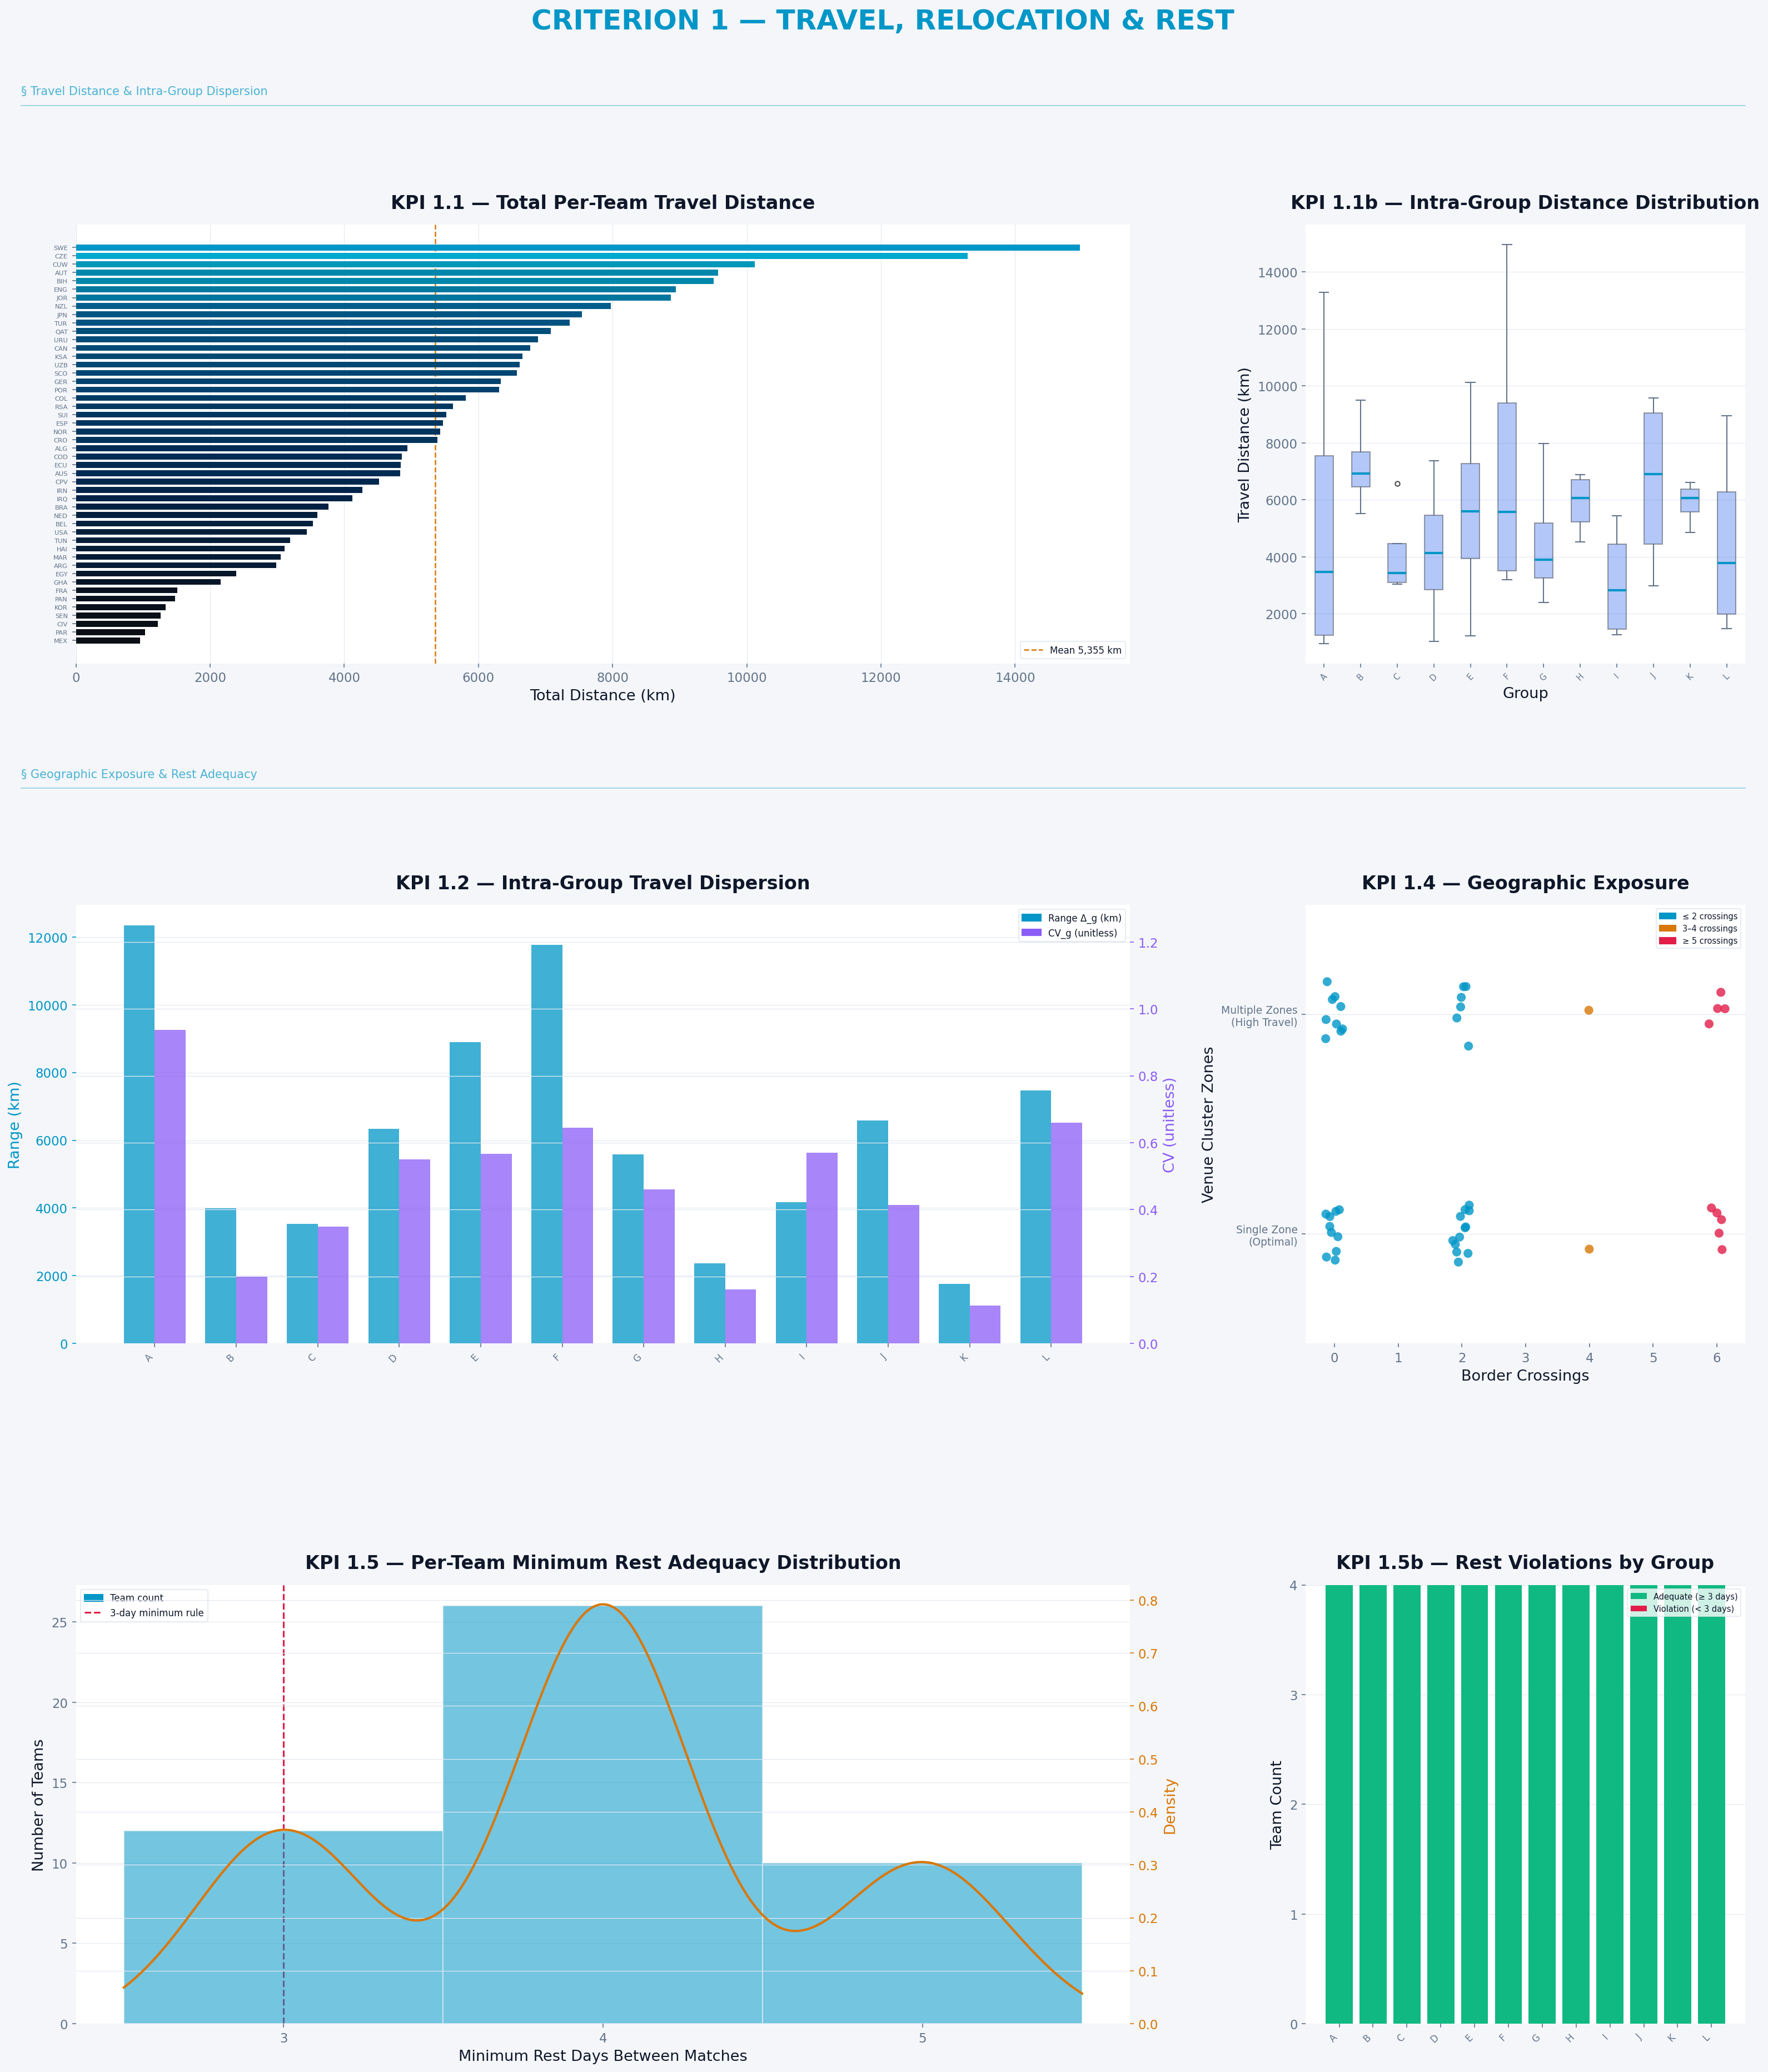

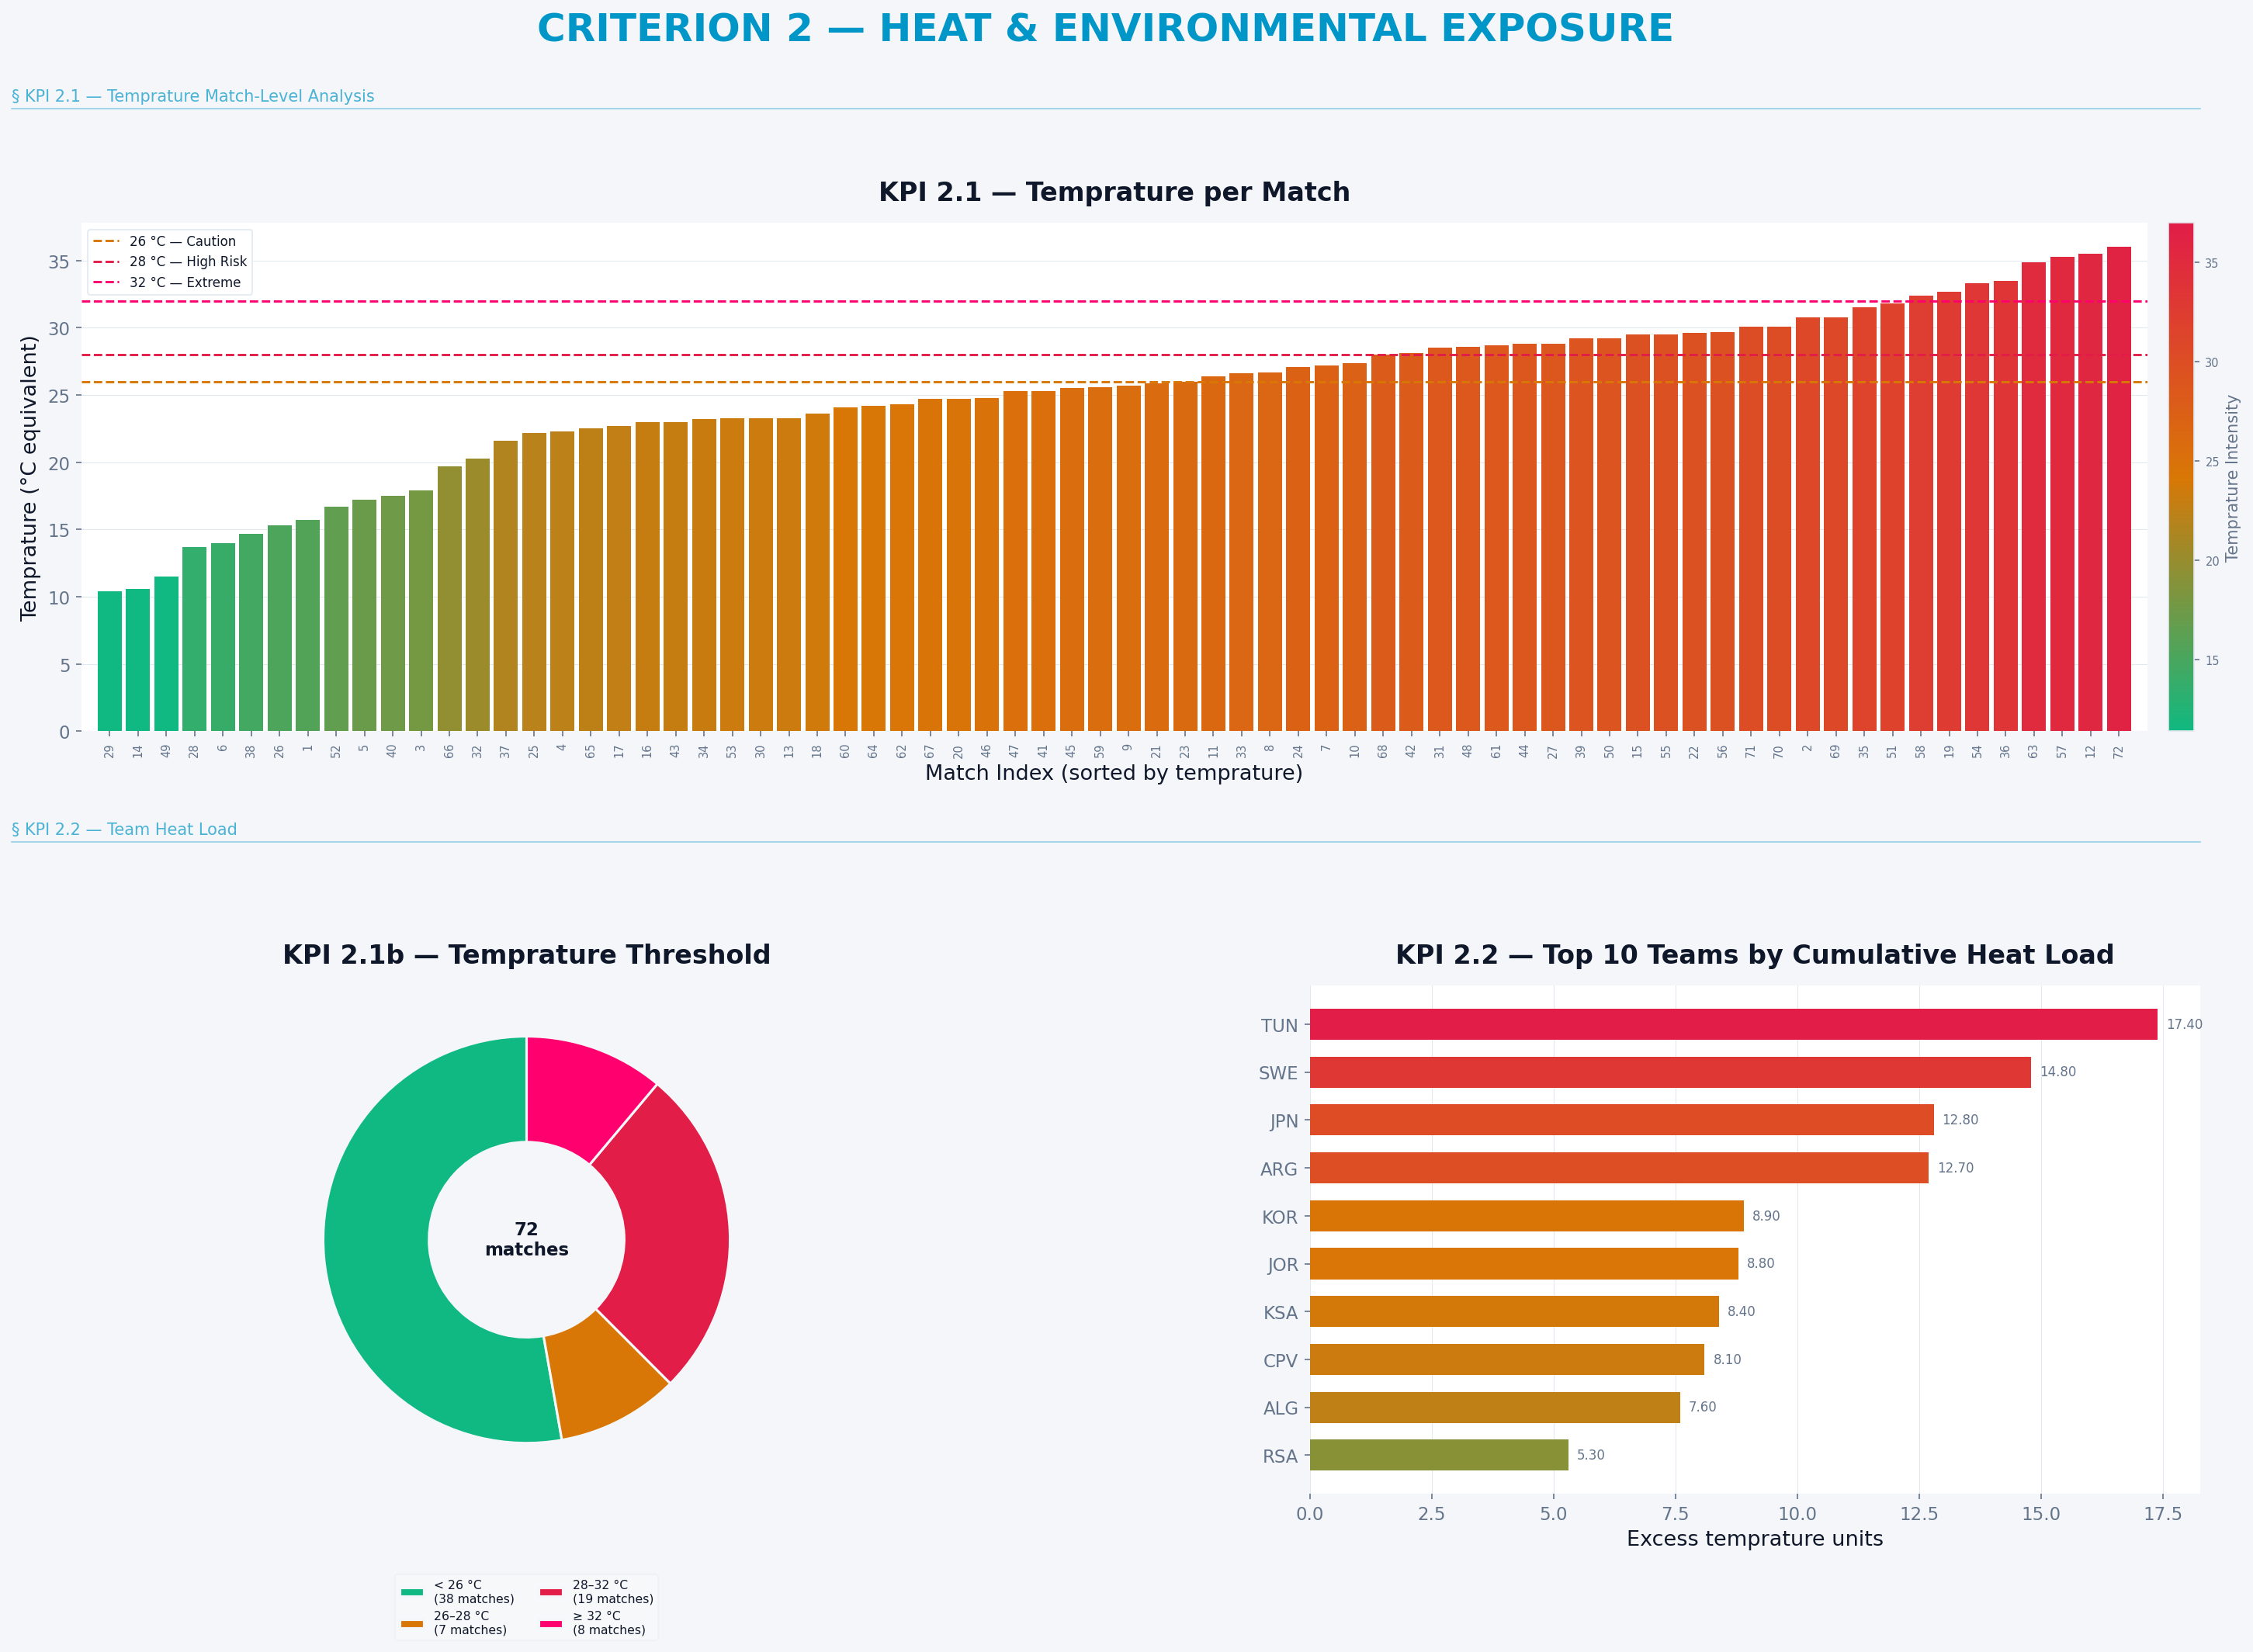

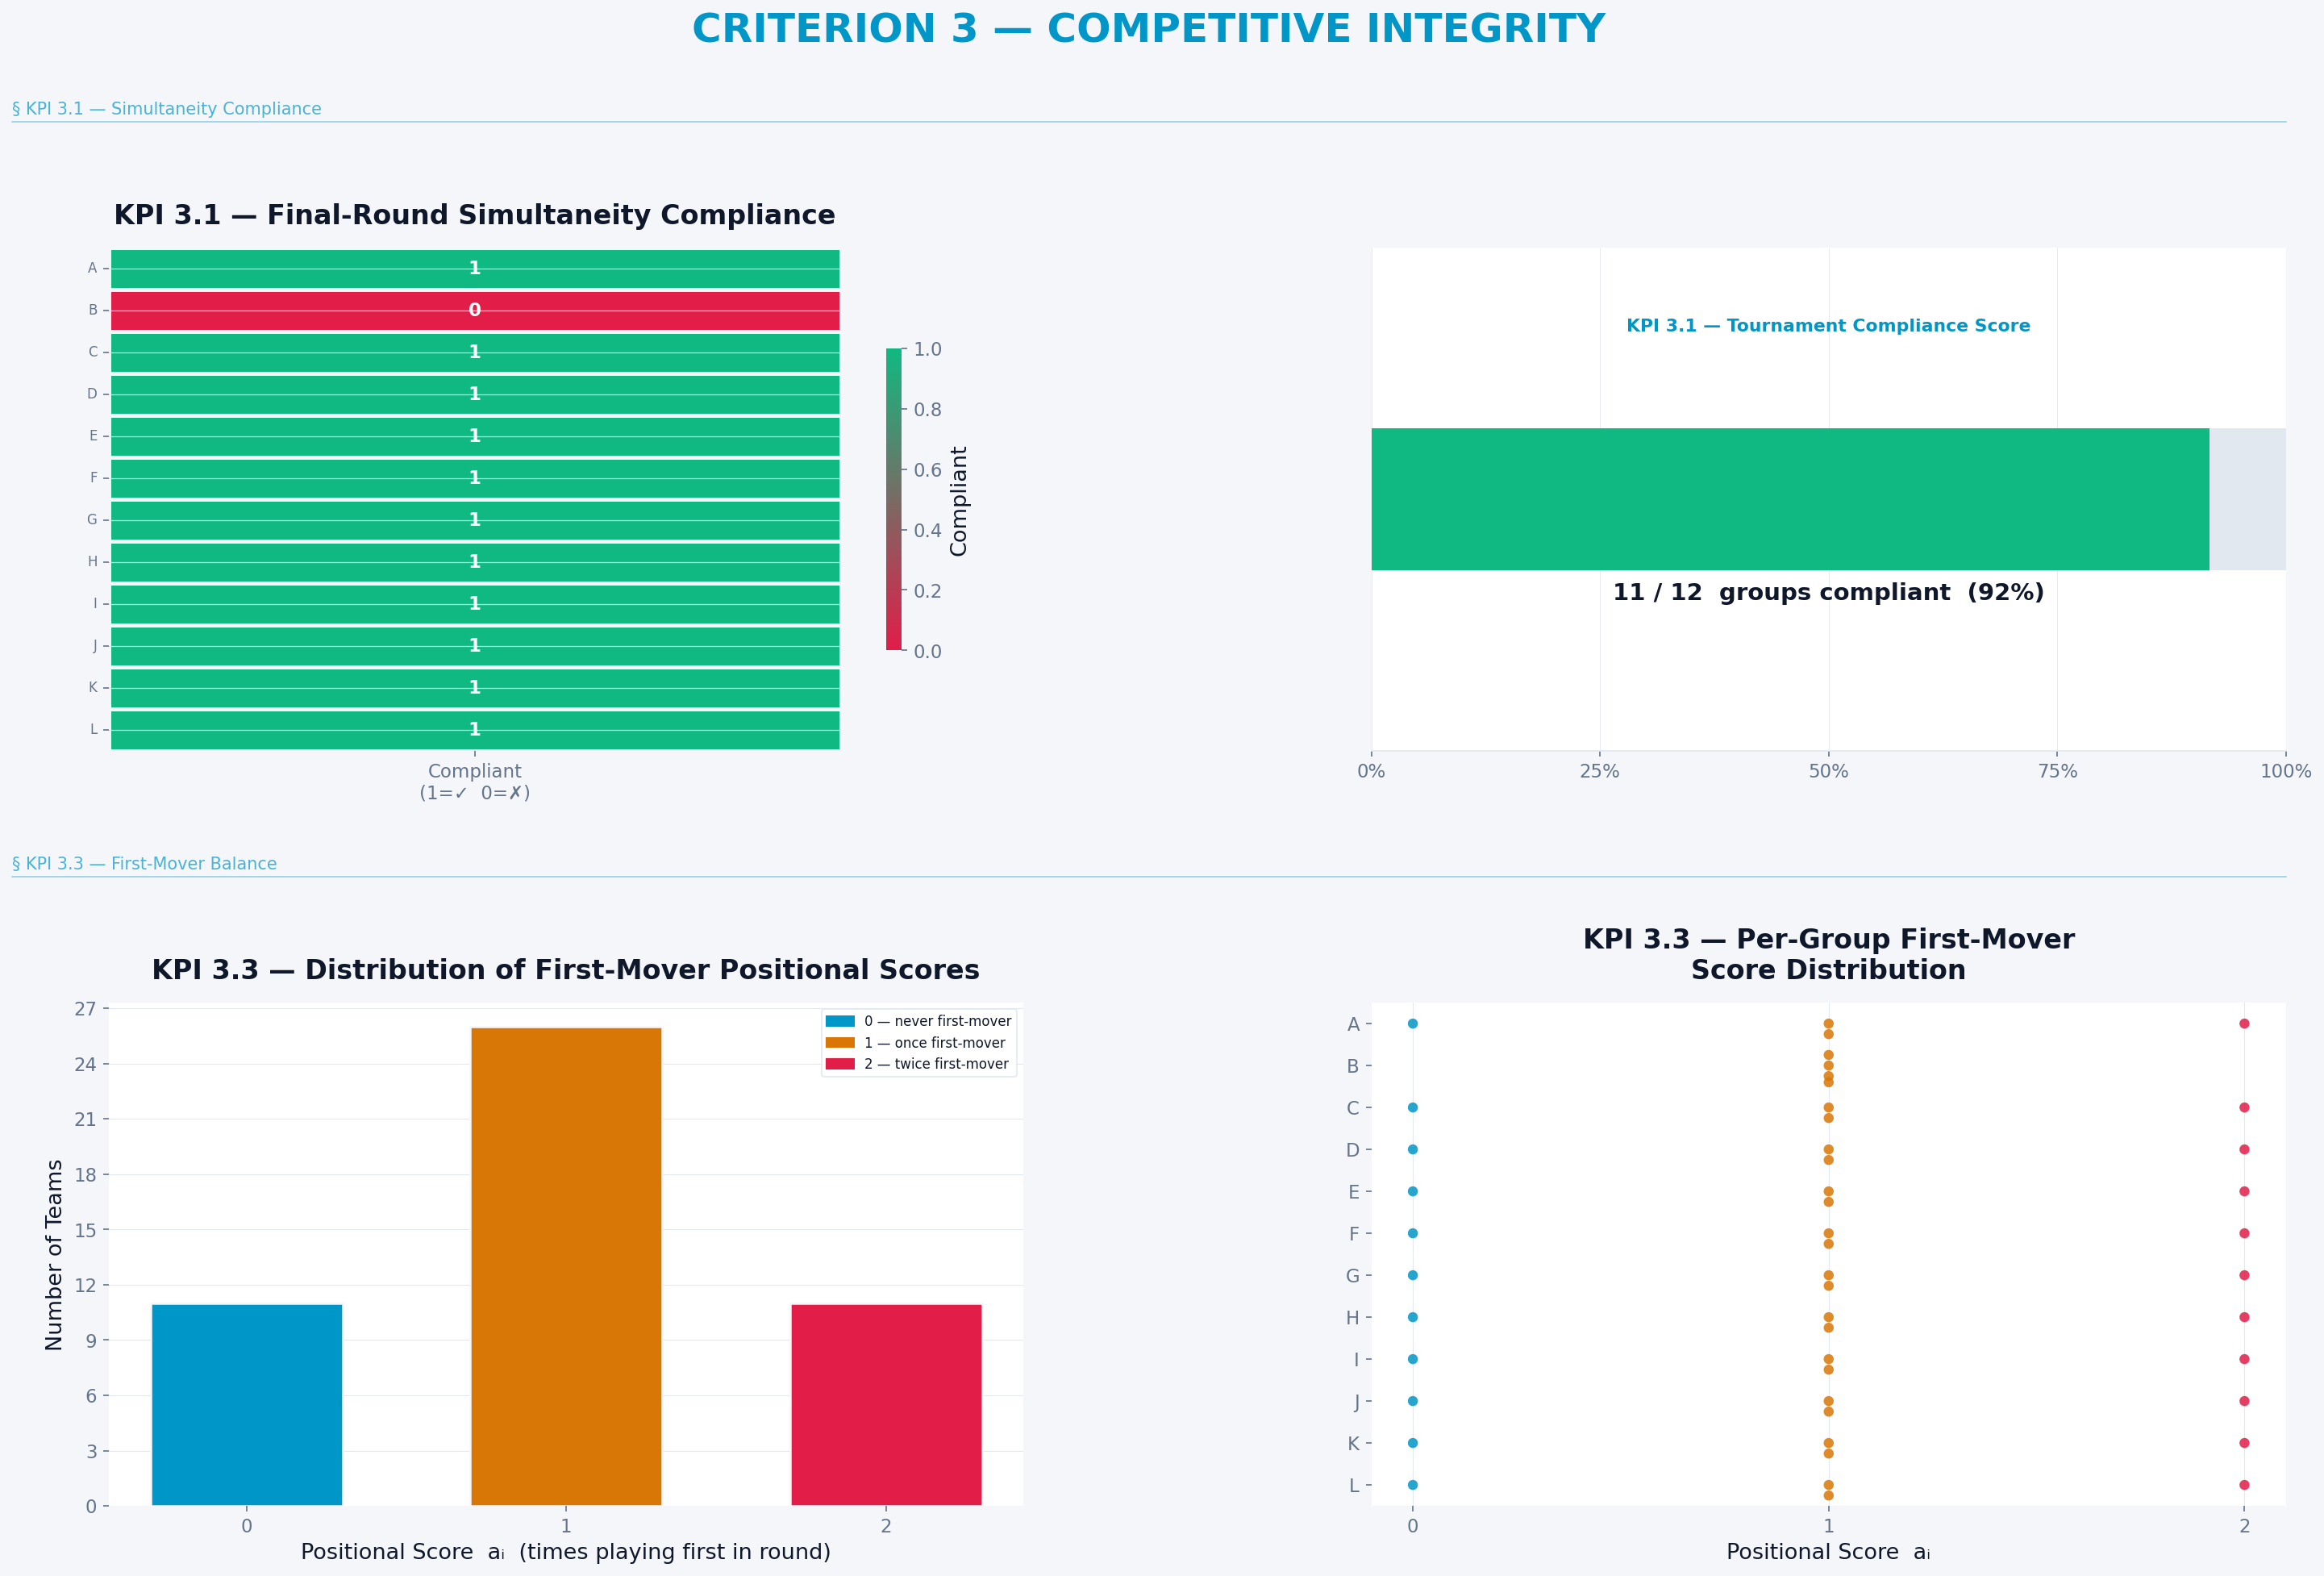

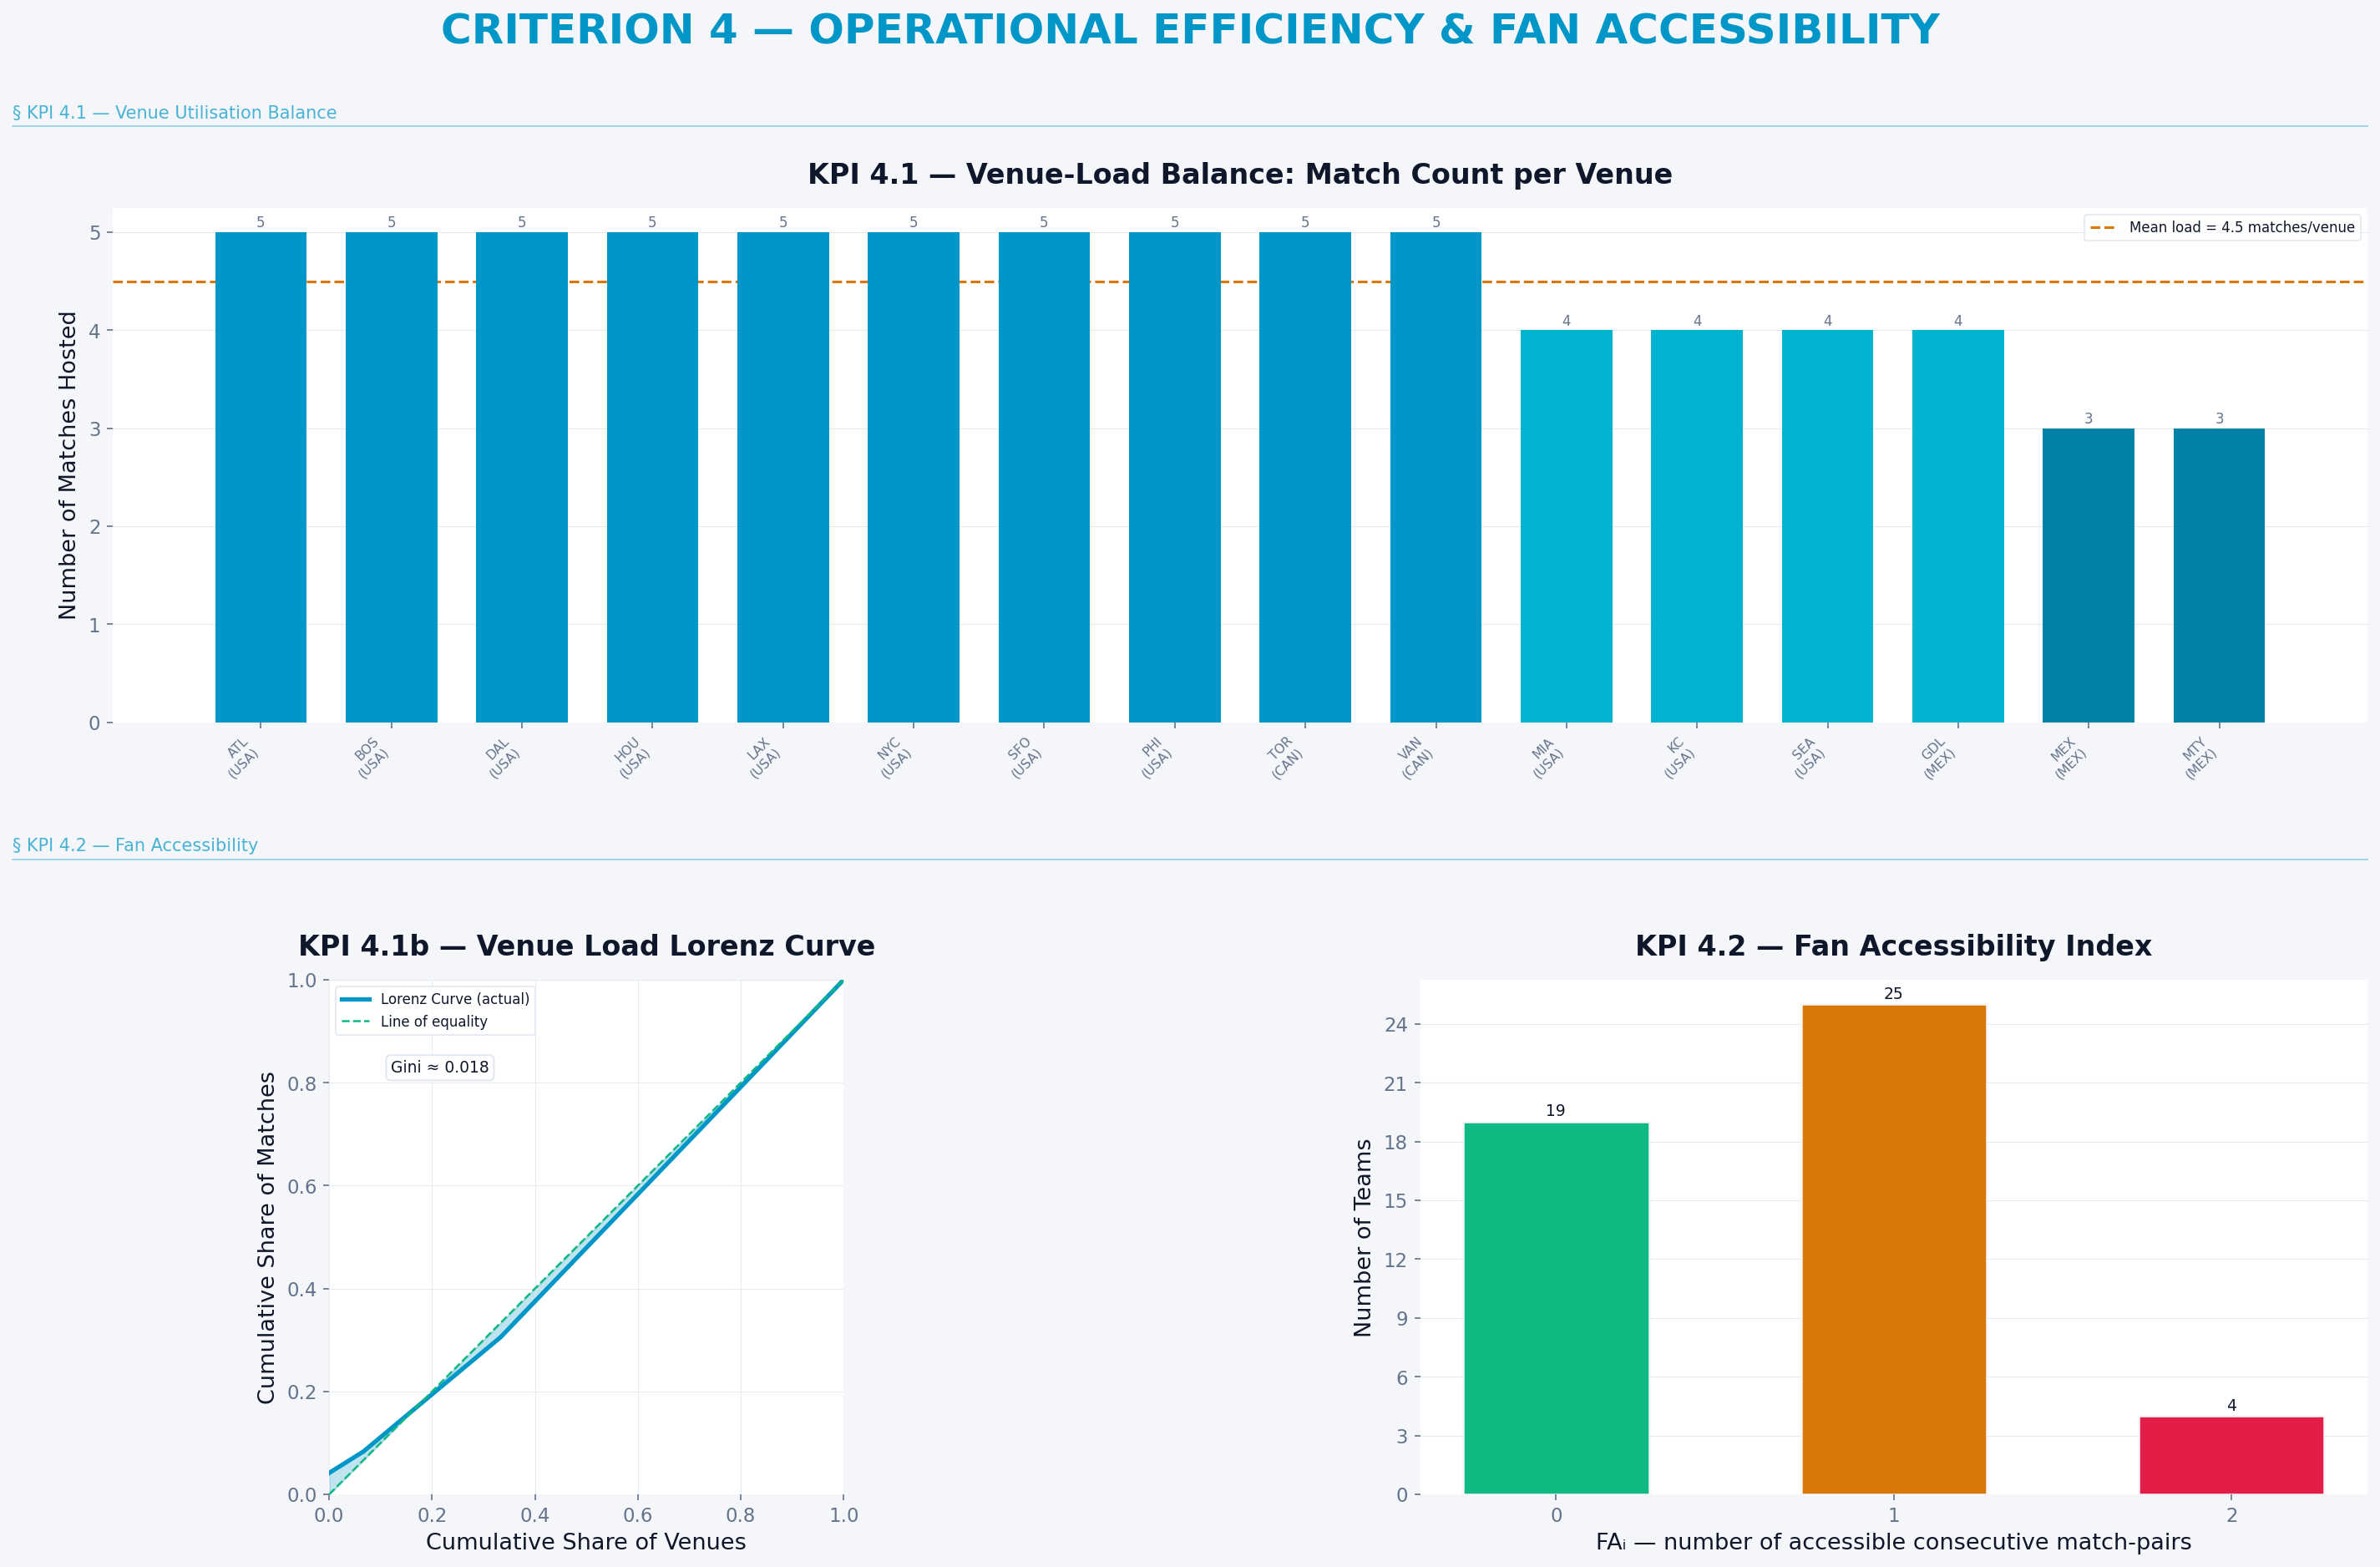

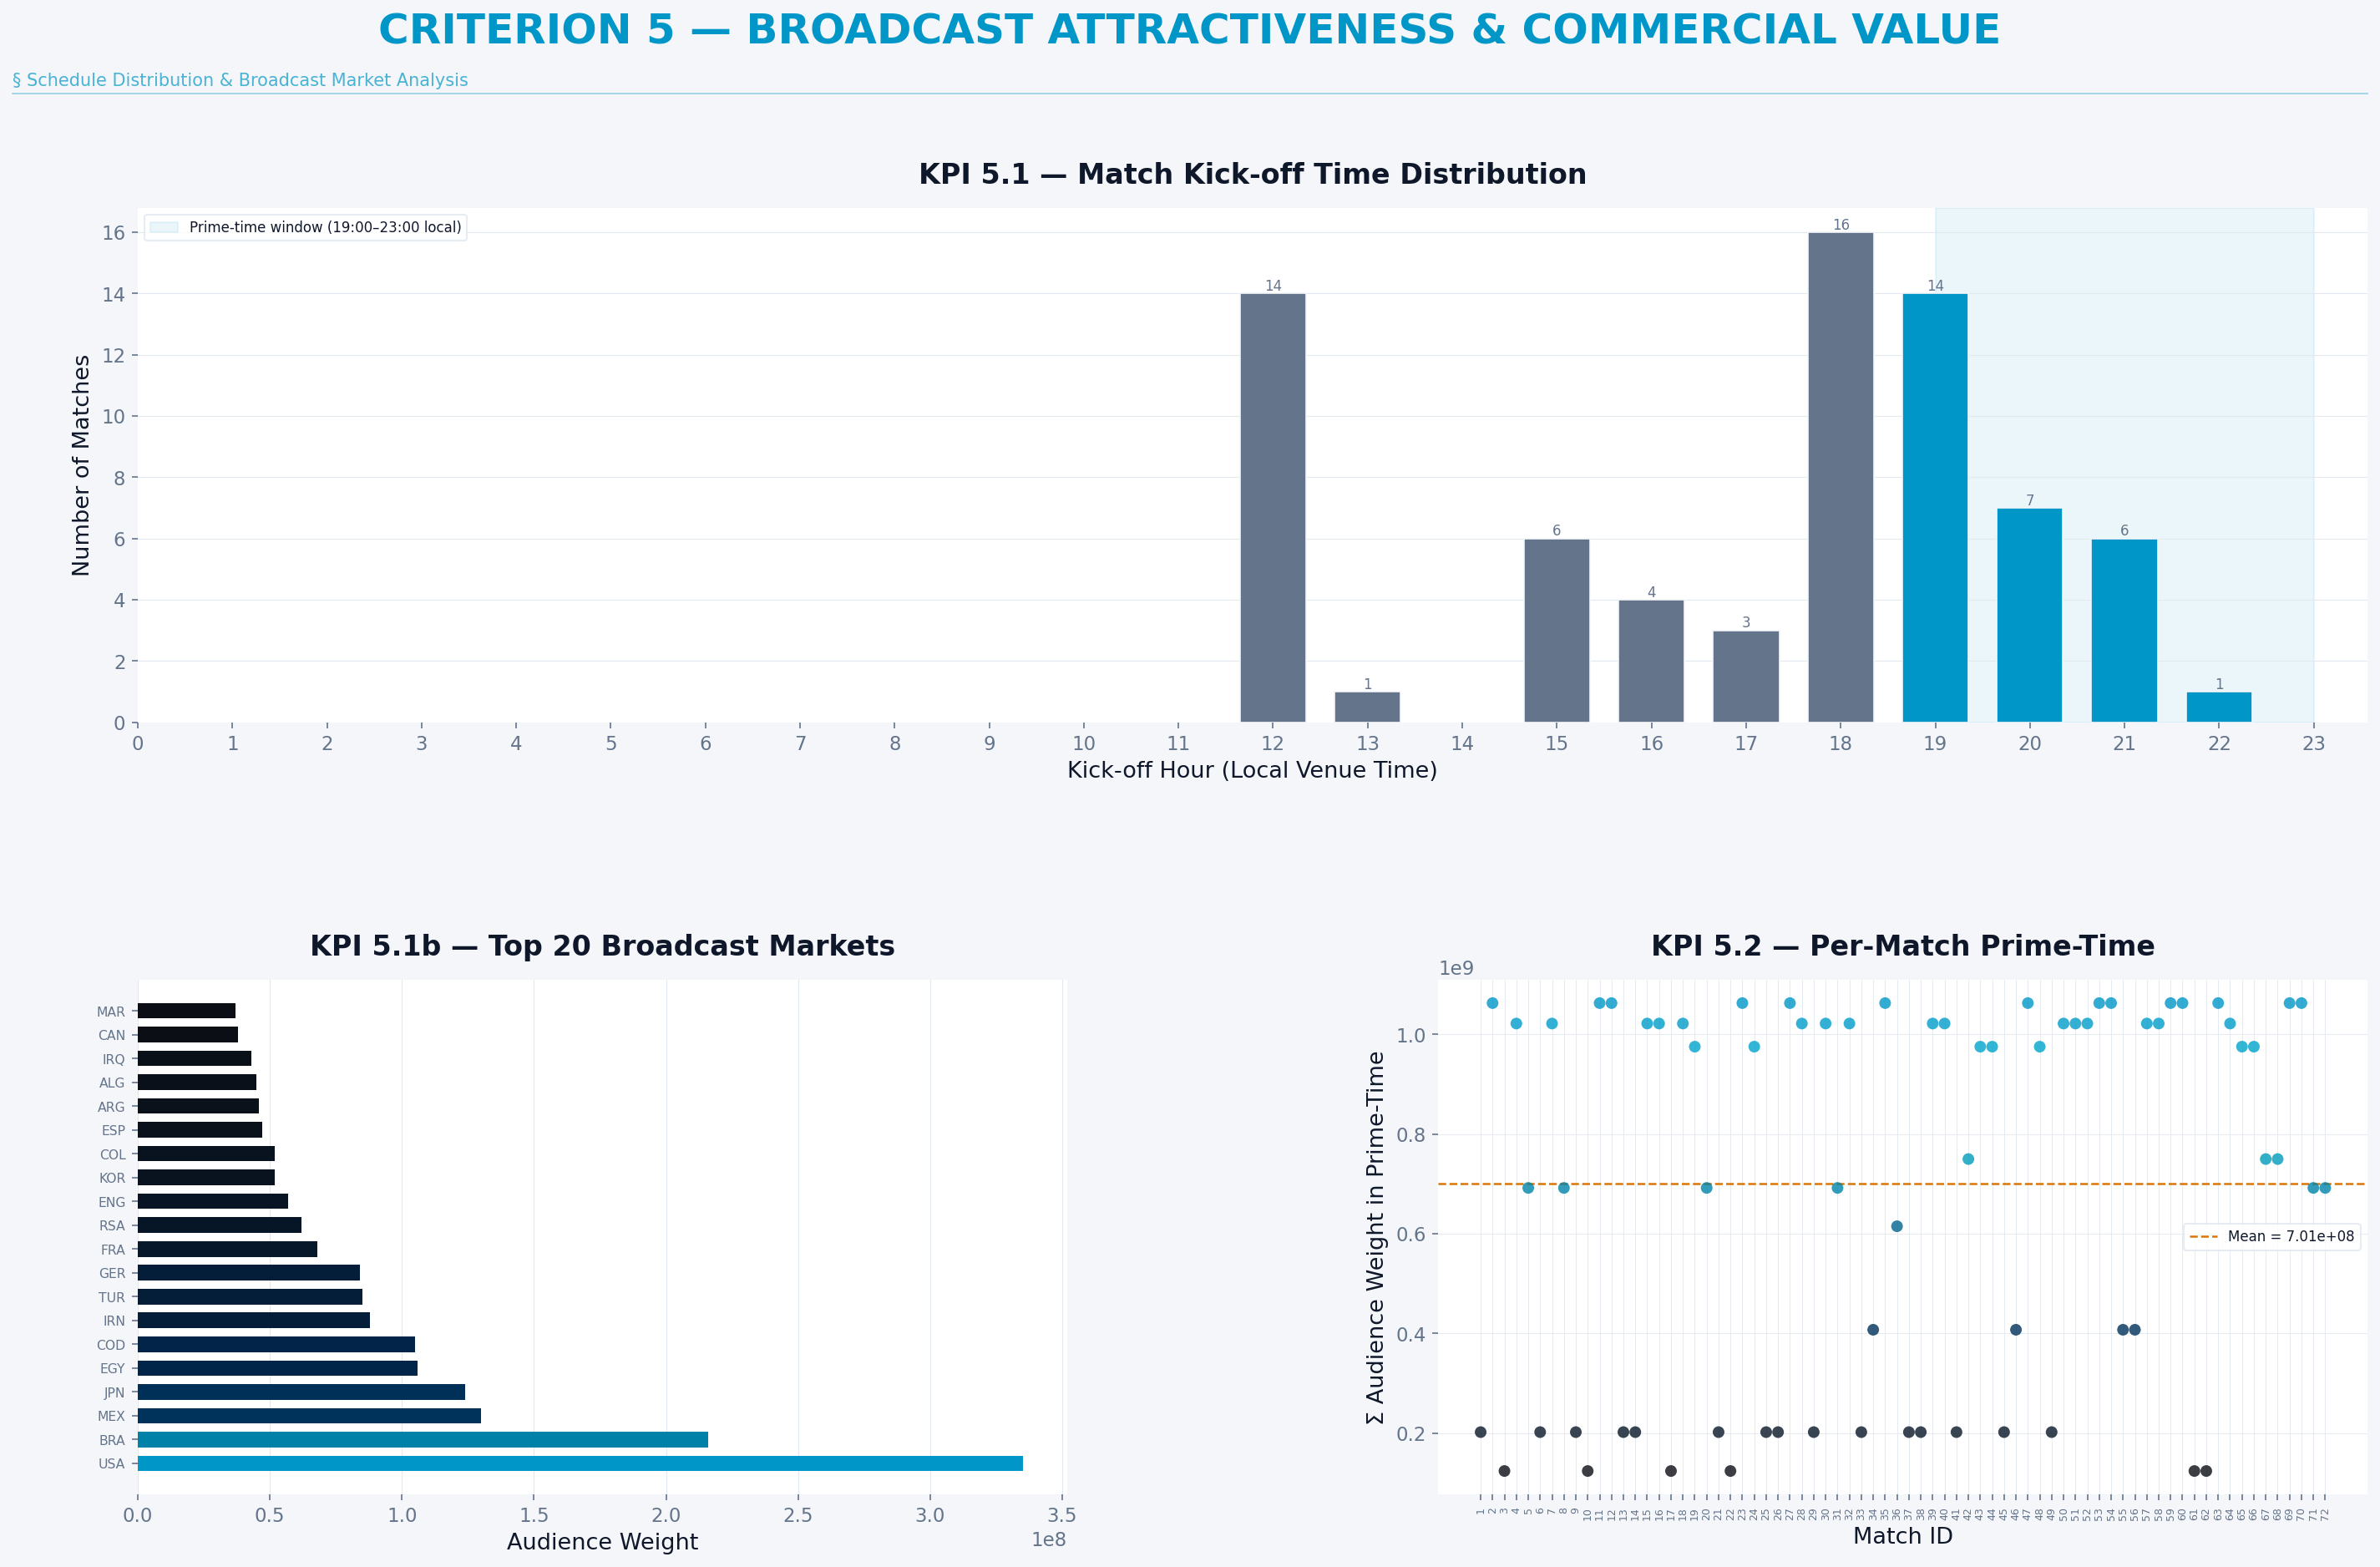

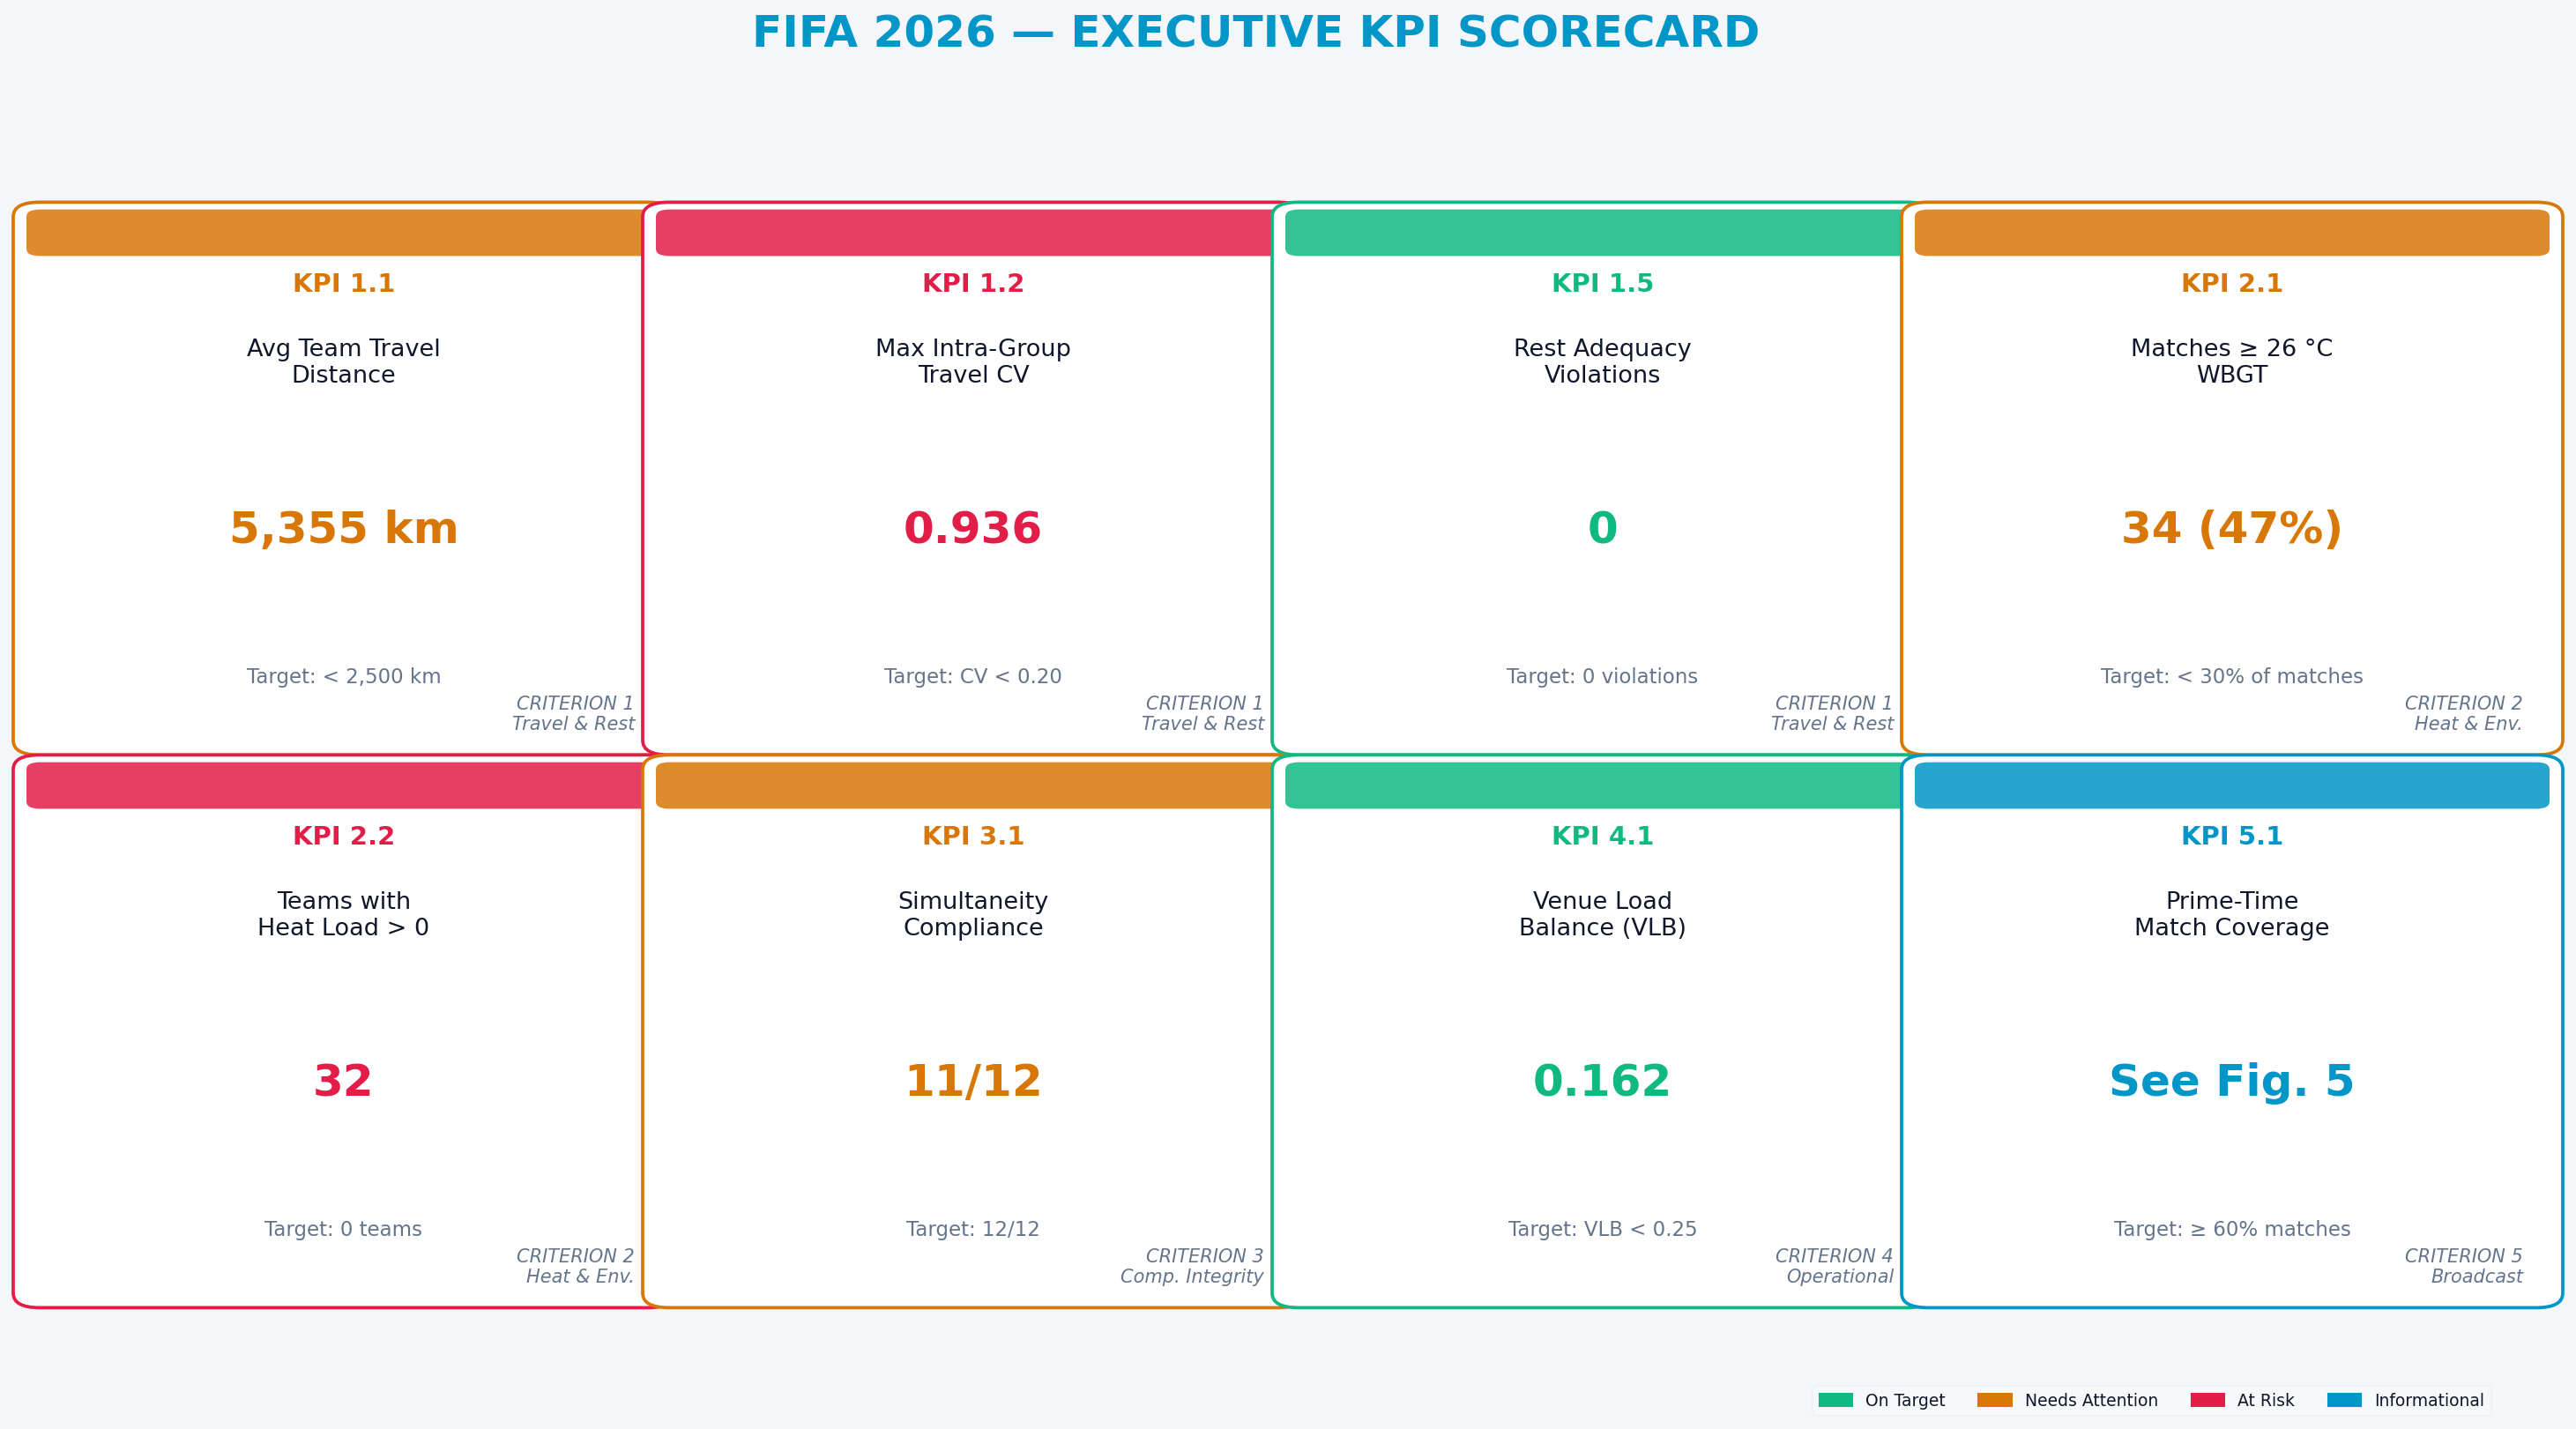

In [20]:
"""
==============================================================================
FIFA 2026 WORLD CUP — KPI VISUALIZATION SUITE
==============================================================================
Author  : Data Science & Visualization Team
Purpose : Executive-level summary dashboard for all EDA KPIs computed in
          FIFA2026_EDA.ipynb
Assumes : All final dictionaries / DataFrames from the EDA notebook are
          already loaded in memory:
              - group_level_statistic  (defaultdict of dicts, keyed by team_id)
              - group_level_data       (defaultdict of dicts, keyed by team_id)
              - matches                (pd.DataFrame)
              - venues                 (pd.DataFrame)
              - teams                  (pd.DataFrame)
              - group_dispersion_stats (dict keyed by group name)
              - sim_results            (dict  group → 0/1 compliance)
              - team_pos_scores        (dict  team_id → int positional score)
              - venue_load             (pd.Series)
              - fa_results             (dict  team_id → int)
              - broadcast_markets      (pd.DataFrame)

Usage   : Run all cells of FIFA2026_EDA.ipynb first, then execute:
              %run fifa2026_kpi_dashboard.py          # inside Jupyter
              python fifa2026_kpi_dashboard.py        # from terminal
==============================================================================
"""

# ── Standard library ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Third-party ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator
import seaborn as sns


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  0 ─  GLOBAL THEME & COLOUR PALETTE (FIFA 2026 branding aesthetic)      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# # ── Palette (dark-mode, high contrast, vibrant accents) ──────────────────────
# MAIN_BG      = "#0B0E14"          # near-black stadium canvas
# PANEL_BG     = "#13181F"          # slightly lighter for axes
# GRID_COLOR   = "#1E2530"          # very subtle grid lines
# ACCENT_CYAN  = "#00E5FF"          # neon cyan — primary highlight
# ACCENT_GREEN = "#39FF14"          # neon green — positive/good KPI
# ACCENT_AMBER = "#FFB300"          # amber — moderate / mid KPI
# ACCENT_RED   = "#FF3D57"          # hot red — alert / high-risk
# ACCENT_PURPLE= "#C653FF"          # violet  — broadcast / commercial
# ACCENT_BLUE  = "#1565FF"          # electric blue — structure
# TEXT_PRIMARY = "#F0F4FA"          # near-white headings
# TEXT_MUTED   = "#6B7A90"          # subtle secondary text

# ── Palette (light-mode, high contrast, vibrant athletic accents) ─────────
MAIN_BG     = "#F4F6F9"          # crisp, cool off-white for the main canvas
PANEL_BG     = "#FFFFFF"          # pure white for the plot axes/panels
GRID_COLOR   = "#E2E8F0"          # very subtle slate gray for grid lines
ACCENT_CYAN  = "#0096C7"          # deepened cyan — primary highlight
ACCENT_GREEN = "#10B981"          # rich athletic green — positive/good KPI
ACCENT_AMBER = "#D97706"          # bold gold/amber — moderate / mid KPI
ACCENT_RED   = "#E11D48"          # sharp crimson — alert / high-risk
ACCENT_PURPLE= "#8B5CF6"          # vibrant violet — broadcast / commercial
ACCENT_BLUE  = "#2563EB"          # electric royal blue — structure
TEXT_PRIMARY = "#0F172A"          # deep slate (near-black) for high legibility headings
TEXT_MUTED   = "#64748B"          # medium slate gray for secondary text/labels

# Gradient colourmap for heatmaps (dark → cyan)
HEATMAP_CM = LinearSegmentedColormap.from_list(
    "fifa_heat", ["#0B0E14", "#00264d", "#005c8a", "#00bcd4", ACCENT_CYAN]
)
# Risk colourmap (green → amber → red)
RISK_CM = LinearSegmentedColormap.from_list(
    "risk", [ACCENT_GREEN, ACCENT_AMBER, ACCENT_RED]
)


def _apply_global_style():
    """Apply the FIFA-2026 dark-mode Matplotlib rcParams."""
    mpl.rcParams.update({
        "figure.facecolor":       MAIN_BG,
        "axes.facecolor":         PANEL_BG,
        "axes.edgecolor":         GRID_COLOR,
        "axes.labelcolor":        TEXT_PRIMARY,
        "axes.titlecolor":        TEXT_PRIMARY,
        "axes.titleweight":       "bold",
        "axes.titlesize":         16,
        "axes.labelsize":         13,
        "axes.spines.top":        False,
        "axes.spines.right":      False,
        "axes.spines.left":       False,
        "axes.spines.bottom":     False,
        "axes.grid":              True,
        "axes.grid.axis":         "y",
        "grid.color":             GRID_COLOR,
        "grid.linewidth":         0.6,
        "xtick.color":            TEXT_MUTED,
        "ytick.color":            TEXT_MUTED,
        "xtick.labelsize":        11,
        "ytick.labelsize":        11,
        "legend.facecolor":       PANEL_BG,
        "legend.edgecolor":       GRID_COLOR,
        "legend.labelcolor":      TEXT_PRIMARY,
        "legend.fontsize":        11,
        "text.color":             TEXT_PRIMARY,
        "font.family":            "DejaVu Sans",
        "figure.dpi":             150,
        "savefig.dpi":            200,
        "savefig.facecolor":      MAIN_BG,
        "savefig.bbox":           "tight",
    })

_apply_global_style()


# ── Helper utilities ──────────────────────────────────────────────────────────

def fig_header(fig, title: str, subtitle: str = ""):
    """Add a top-level figure title + subtitle banner."""
    fig.text(
        0.5, 0.98, title,
        ha="center", va="top",
        fontsize=24, fontweight="bold", color=ACCENT_CYAN,
        transform=fig.transFigure
    )
    if subtitle:
        fig.text(
            0.5, 0.955, subtitle,
            ha="center", va="top",
            fontsize=12, color=TEXT_MUTED,
            transform=fig.transFigure
        )


def annotate_insight(ax, text: str, xy=(0.5, 0.02), fontsize=8):
    """Add a small italic insight annotation inside an axes."""
    text = ""
    ax.annotate(
        text, xy=xy, xycoords="axes fraction",
        ha="center", va="bottom",
        fontsize=fontsize, style="italic", color=TEXT_MUTED,
        bbox=dict(boxstyle="round,pad=0.3", fc=MAIN_BG, ec=GRID_COLOR, alpha=0.7)
    )


def bar_gradient(ax, values, labels, cmap, title, xlabel, note=""):
    """
    Horizontal bar chart with a left-to-right colour gradient
    (intensity ∝ value magnitude).  Returns the axes.
    """
    norm = mpl.colors.Normalize(vmin=min(values), vmax=max(values))
    colours = [cmap(norm(v)) for v in values]
    bars = ax.barh(labels, values, color=colours, height=0.65, zorder=3)
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()                  # highest value at top
    ax.grid(axis="x", color=GRID_COLOR, lw=0.5, zorder=0)
    ax.grid(axis="y", visible=False)
    # Value labels on bars
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + 0.01 * max(values),
            bar.get_y() + bar.get_height() / 2,
            f"{val:,.1f}",
            va="center", fontsize=8, color=TEXT_MUTED
        )
    if note:
        annotate_insight(ax, note)
    return ax


def section_divider(fig, y: float, label: str):
    """Draw a thin neon line with section label across the figure."""
    line = mpl.lines.Line2D(
        [0.03, 0.97], [y, y],
        transform=fig.transFigure,
        color=ACCENT_CYAN, lw=0.8, alpha=0.4
    )
    fig.add_artist(line)
    fig.text(0.03, y + 0.005, label, fontsize=10,
             color=ACCENT_CYAN, alpha=0.7, transform=fig.transFigure)


# def save_subplot(ax, filename):
#     fig = ax.figure
#     fig.canvas.draw()
#
#     renderer = fig.canvas.get_renderer()
#
#     artists = [ax]
#
#     artists.extend(ax.texts)
#
#     if ax.get_legend() is not None:
#         artists.append(ax.get_legend())
#
#     bbox = Bbox.union([
#         artist.get_tightbbox(renderer)
#         for artist in artists
#         if artist.get_tightbbox(renderer) is not None
#     ])
#
#     bbox = bbox.expanded(1.15, 1.15)
#
#     fig.savefig(
#         filename,
#         format="pdf",
#         bbox_inches=bbox.transformed(
#             fig.dpi_scale_trans.inverted()
#         ),
#         facecolor="white", # fig.get_facecolor(),
#         edgecolor="white",
#     )
#
# def save_all_subplots(fig, output_dir, subplot_names):
#     """
#     Save every subplot in a figure.
#
#     Parameters
#     ----------
#     fig : matplotlib Figure
#     output_dir : str
#     subplot_names : list[str]
#         Names matching fig.axes order.
#     """
#     os.makedirs(output_dir, exist_ok=True)
#
#     for ax, name in zip(fig.axes, subplot_names):
#         filepath = os.path.join(output_dir, f"{name}.pdf")
#         save_subplot(ax, filepath)
#         print(f"      ↳ {filepath}")

def save_subplot(ax, filename):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # 1. Identify all axes that belong to this plot (Main + Twins + Colorbars)
    target_axes = [ax]
    ax_bbox = ax.get_position()

    for other_ax in fig.axes:
        if other_ax is ax:
            continue

        other_bbox = other_ax.get_position()

        # Condition A: It is a twin axis (shares the exact same plotting footprint)
        is_twin = (other_bbox.bounds == ax_bbox.bounds)

        # Condition B: It is a colorbar attached to this specific axis
        # (Checks if it sits closely to the right of the main axis)
        is_attached_cbar = (
            other_ax.get_label() == '<colorbar>' and
            abs(other_bbox.x0 - ax_bbox.x1) < 0.1
        )

        if is_twin or is_attached_cbar:
            target_axes.append(other_ax)

    # 2. Temporarily hide all other subplots to completely prevent "bleeding"
    original_visibility = {}
    for a in fig.axes:
        original_visibility[a] = a.get_visible()
        if a not in target_axes:
            a.set_visible(False)

    # Redraw the figure with only our target elements visible
    fig.canvas.draw()

    # 3. Calculate the exact bounding box of everything in the target axes
    artists = []
    for t_ax in target_axes:
        artists.append(t_ax)
        artists.extend(t_ax.texts)
        if t_ax.get_legend() is not None:
            artists.append(t_ax.get_legend())

    bbox = Bbox.union([
        artist.get_tightbbox(renderer)
        for artist in artists
        if artist.get_tightbbox(renderer) is not None
    ])

    # 4. FIX: Use 2% padding instead of 15%.
    # 1.02 gives a crisp border without expanding into neighboring plots
    bbox = bbox.expanded(1.02, 1.02)

    # 5. Save the cropped area
    fig.savefig(
        filename,
        format="pdf",
        bbox_inches=bbox.transformed(fig.dpi_scale_trans.inverted()),
        facecolor="white",
        edgecolor="white",
    )

    # 6. Restore the overall figure to its normal visible state
    for a, vis in original_visibility.items():
        a.set_visible(vis)


def save_all_subplots(fig, output_dir, subplot_names):
    """
    Save every primary subplot in a figure.
    """
    os.makedirs(output_dir, exist_ok=True)

    # FIX: Filter out twin axes and colorbars from the loop!
    # We can easily filter for primary axes because they all have titles.
    primary_axes = [a for a in fig.axes if a.get_title() != ""]

    for ax, name in zip(primary_axes, subplot_names):
        filepath = os.path.join(output_dir, f"{name}.pdf")
        save_subplot(ax, filepath)
        print(f"      ↳ {filepath}")


# ── Build a flat DataFrame from group_level_statistic ─────────────────────────

def build_summary_df(group_level_statistic, group_level_data):
    """
    Flatten group_level_statistic + group_level_data into one tidy DataFrame.
    Each row is one team.
    """
    records = []
    for tid, stats in group_level_statistic.items():
        meta = group_level_data.get(tid, {})
        row = {"team_id": tid}
        row["team_name"]      = meta.get("name", tid)
        row["group"]          = meta.get("group", "?")
        row["fifa_ranking"]   = meta.get("fifa_ranking", np.nan)
        # KPI 1.1
        row["total_distance"] = stats.get("total_distance", np.nan)
        # KPI 1.4
        row["num_zones"]      = stats.get("num_zomnes", np.nan)      # note: typo in notebook preserved
        row["border_crossings"] = stats.get("border_crossings", np.nan)
        # KPI 1.5
        row["min_rest"]       = stats.get("min_rest", 0)
        # KPI 2.2 — key may include the TAU value
        heat_key = [k for k in stats if "wbgt>" in k]
        row["heat_load"]      = stats.get(heat_key[0], 0.0) if heat_key else 0.0
        # KPI 3.3
        row["pos_score"]      = stats.get("pos_score", 0)

        records.append(row)

    df = pd.DataFrame(records)
    return df


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 1 — CRITERION 1 · Travel, Relocation & Rest  (3 × 2 grid)      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def plot_criterion1(df: pd.DataFrame,
                    group_dispersion_stats: dict) -> plt.Figure:
    """
    Six panels covering all Travel / Rest KPIs.

    Visual rationale
    ─────────────────
    • KPI 1.1 — Horizontal bar (sorted): clearly ranks 48 teams by total
      burden; gradient colour signals intensity at a glance.
    • KPI 1.1 — Boxplot by group: reveals intra-group dispersion (fairness),
      which a plain bar would hide.
    • KPI 1.2 — Grouped bar (range + CV): two complementary dispersion metrics
      side-by-side per group; dual y-axes keep different units readable.
    • KPI 1.4 zones/crossings — Scatter: highlights multi-dimensional exposure
      (zones × crossings) simultaneously.
    • KPI 1.5 — Histogram + KDE: rest days are discrete; a histogram + KDE
      shows the full distribution, not just extreme cases.
    • KPI 1.5 — Stacked bar by group: reveals which groups share the "< 3 day"
      rest violation burden.
    """
    fig = plt.figure(figsize=(22, 26))
    fig.patch.set_facecolor(MAIN_BG)
    fig_header(fig,
               "CRITERION 1 — TRAVEL, RELOCATION & REST",
               "")
    section_divider(fig, 0.935, "§ Travel Distance & Intra-Group Dispersion")
    section_divider(fig, 0.62,  "§ Geographic Exposure & Rest Adequacy")

    gs = gridspec.GridSpec(
        3, 3,
        figure=fig,
        top=0.88, bottom=0.05,
        left=0.06, right=0.97,
        hspace=0.55, wspace=0.4
    )

    sub_df = df.dropna(subset=["total_distance"]).sort_values("total_distance", ascending=True)

    # ── Panel 1.1a : Horizontal bar — All teams total distance ────────────────
    ax1 = fig.add_subplot(gs[0, :2])   # spans 2 columns
    n_show = min(48, len(sub_df))
    show_df = sub_df.tail(n_show)      # top (most-travelled) at right after invert
    norm_dist = mpl.colors.Normalize(
        vmin=show_df["total_distance"].min(),
        vmax=show_df["total_distance"].max()
    )
    colours = [HEATMAP_CM(norm_dist(v)) for v in show_df["total_distance"]]
    bars = ax1.barh(show_df["team_id"], show_df["total_distance"],
                    color=colours, height=0.7, zorder=3)
    ax1.set_title("KPI 1.1 — Total Per-Team Travel Distance", pad=14)
    ax1.set_xlabel("Total Distance (km)")
    ax1.axvline(sub_df["total_distance"].mean(), color=ACCENT_AMBER,
                lw=1.2, ls="--", label=f"Mean {sub_df['total_distance'].mean():,.0f} km")
    ax1.legend(loc="lower right", fontsize=8)
    ax1.grid(axis="x", color=GRID_COLOR, lw=0.5, zorder=0)
    ax1.grid(axis="y", visible=False)
    ax1.tick_params(axis="y", labelsize=5.5)
    # annotate_insight(ax1,
    #     "Higher bar → more total travel burden over group stage",
    #     xy=(0.72, 1.02), fontsize=8)

    # ── Panel 1.1b : Boxplot by group ────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    groups_sorted = sorted(df["group"].dropna().unique())
    data_by_group = [df[df["group"] == g]["total_distance"].dropna().values
                     for g in groups_sorted]
    bp = ax2.boxplot(
        data_by_group,
        patch_artist=True,
        medianprops=dict(color=ACCENT_CYAN, lw=2),
        whiskerprops=dict(color=TEXT_MUTED),
        capprops=dict(color=TEXT_MUTED),
        flierprops=dict(marker="o", color=ACCENT_RED, ms=4, alpha=0.7),
        labels=groups_sorted
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(ACCENT_BLUE)
        patch.set_alpha(0.35)
    ax2.set_title("KPI 1.1b — Intra-Group Distance Distribution", pad=14)
    ax2.set_xlabel("Group")
    ax2.set_ylabel("Travel Distance (km)")
    ax2.tick_params(axis="x", labelsize=7, rotation=45)
    ax2.grid(axis="y", color=GRID_COLOR, lw=0.5)
    # annotate_insight(ax2, "Wide box = large fairness gap", xy=(0.5, -0.22))

    # ── Panel 1.2 : Grouped bar — Range & CV per group ───────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    groups_d = sorted(group_dispersion_stats.keys())
    range_vals = [group_dispersion_stats[g]["range"] for g in groups_d]
    cv_vals    = [group_dispersion_stats[g]["cv"]    for g in groups_d]
    x = np.arange(len(groups_d))
    w = 0.38
    bars_r = ax3.bar(x - w/2, range_vals, w, color=ACCENT_CYAN,
                     alpha=0.75, label="Range Δ_g (km)", zorder=3)
    ax3_r = ax3.twinx()
    bars_c = ax3_r.bar(x + w/2, cv_vals, w, color=ACCENT_PURPLE,
                        alpha=0.75, label="CV_g (unitless)", zorder=3)
    ax3.set_title("KPI 1.2 — Intra-Group Travel Dispersion", pad=14)
    ax3.set_xticks(x)
    ax3.set_xticklabels(groups_d, fontsize=8, rotation=45, ha="right")
    ax3.set_ylabel("Range (km)", color=ACCENT_CYAN)
    ax3_r.set_ylabel("CV (unitless)", color=ACCENT_PURPLE)
    ax3_r.tick_params(axis="y", colors=ACCENT_PURPLE)
    ax3.tick_params(axis="y", colors=ACCENT_CYAN)
    ax3.yaxis.label.set_color(ACCENT_CYAN)
    ax3_r.set_ylim(0, max(cv_vals) * 1.4 if cv_vals else 1)
    handles = [mpatches.Patch(color=ACCENT_CYAN,   label="Range Δ_g (km)"),
               mpatches.Patch(color=ACCENT_PURPLE, label="CV_g (unitless)")]
    ax3.legend(handles=handles, loc="upper right", fontsize=8)
    ax3.grid(axis="y", color=GRID_COLOR, lw=0.5, zorder=0)
    annotate_insight(ax3,
        "Lower Range & CV → fairer scheduling within a group",
        xy=(0.5, -0.30))

    # ── Panel 1.4 : Scatter — Zones vs Border Crossings ──────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    sc_df = df.dropna(subset=["num_zones", "border_crossings"])
    scatter_c = [ACCENT_CYAN if r <= 2 else ACCENT_AMBER if r <= 4 else ACCENT_RED
                 for r in sc_df["border_crossings"]]
    # Generate random jitter between -0.15 and 0.15
    jitter_x = np.random.uniform(-0.15, 0.15, size=len(sc_df))
    jitter_y = np.random.uniform(-0.15, 0.15, size=len(sc_df))

    ax4.scatter(
        sc_df["border_crossings"] + jitter_x, # Apply jitter to X
        sc_df["num_zones"] + jitter_y,        # Apply jitter to Y
        c=scatter_c, s=60, alpha=0.8, edgecolors="none", zorder=4
    )
    # ax4.scatter(
    #     sc_df["border_crossings"], sc_df["num_zones"],
    #     c=scatter_c, s=60, alpha=0.8, edgecolors="none", zorder=4
    # )
    # Jitter to avoid perfect overlap
    ax4.set_title("KPI 1.4 — Geographic Exposure", pad=14)
    ax4.set_xlabel("Border Crossings")
    ax4.set_ylabel("Venue Cluster Zones")
    ax4.xaxis.set_major_locator(MaxNLocator(integer=True))
    # ax4.yaxis.set_major_locator(MaxNLocator(integer=True))
    # Explicitly set the tick locations for 1 and 2
    ax4.set_yticks([1, 2])

    # Map those locations to your professional text labels
    ax4.set_yticklabels(["Single Zone\n(Optimal)", "Multiple Zones\n(High Travel)"], fontsize=9)

    # (Optional but recommended) Add a little padding to the top and bottom of the plot
    # so the dots don't touch the very edges of the graph
    ax4.set_ylim(0.5, 2.5)
    legend_elems = [
        mpatches.Patch(color=ACCENT_CYAN,  label="≤ 2 crossings"),
        mpatches.Patch(color=ACCENT_AMBER, label="3–4 crossings"),
        mpatches.Patch(color=ACCENT_RED,   label="≥ 5 crossings"),
    ]
    ax4.legend(handles=legend_elems, fontsize=7)
    annotate_insight(ax4, "Top-right → highest logistical burden", xy=(0.5, -0.22))

    # ── Panel 1.5a : Histogram + KDE — Min Rest Days distribution ────────────
    ax5 = fig.add_subplot(gs[2, :2])
    rest_vals = df["min_rest"].dropna().astype(int)
    bins = range(rest_vals.min(), rest_vals.max() + 2)
    ax5.hist(rest_vals, bins=bins, align="left",
             color=ACCENT_CYAN, alpha=0.55, edgecolor=MAIN_BG, zorder=3,
             label="Team count")
    # KDE overlay (continuous approximation)
    from scipy.stats import gaussian_kde
    kde_x = np.linspace(rest_vals.min() - 0.5, rest_vals.max() + 0.5, 300)
    kde   = gaussian_kde(rest_vals, bw_method=0.4)
    ax5_r = ax5.twinx()
    ax5_r.plot(kde_x, kde(kde_x), color=ACCENT_AMBER, lw=2, label="KDE")
    ax5_r.set_ylabel("Density", color=ACCENT_AMBER)
    ax5_r.tick_params(axis="y", colors=ACCENT_AMBER)
    ax5_r.set_ylim(0)
    # Threshold line
    ax5.axvline(3, color=ACCENT_RED, lw=1.5, ls="--", label="3-day minimum rule")
    ax5.set_title("KPI 1.5 — Per-Team Minimum Rest Adequacy Distribution", pad=14)
    ax5.set_xlabel("Minimum Rest Days Between Matches")
    ax5.set_ylabel("Number of Teams")
    ax5.xaxis.set_major_locator(MaxNLocator(integer=True))
    handles = [mpatches.Patch(color=ACCENT_CYAN,  label="Team count"),
               mlines_stub := mpl.lines.Line2D([], [], color=ACCENT_RED,
                                                ls="--", label="3-day rule")]
    ax5.legend(handles=[handles[0], handles_stub := mpl.lines.Line2D(
        [], [], color=ACCENT_RED, ls="--", label="3-day minimum rule")],
        fontsize=8, loc="upper left")
    ax5.grid(axis="y", color=GRID_COLOR, lw=0.5, zorder=0)
    annotate_insight(ax5,
        "Teams left of the red dashed line violate FIFA rest protocol",
        xy=(0.5, -0.18))

    # ── Panel 1.5b : Stacked bar — Rest adequacy by group ────────────────────
    ax6 = fig.add_subplot(gs[2, 2])
    THRESHOLD = 3
    group_rest = {}
    for g in groups_sorted:
        vals = df[df["group"] == g]["min_rest"].dropna()
        group_rest[g] = {
            "adequate": (vals >= THRESHOLD).sum(),
            "violation": (vals < THRESHOLD).sum()
        }
    grp_labels = sorted(group_rest.keys())
    adequate  = [group_rest[g]["adequate"]  for g in grp_labels]
    violation = [group_rest[g]["violation"] for g in grp_labels]
    x_pos = np.arange(len(grp_labels))
    ax6.bar(x_pos, adequate,  color=ACCENT_GREEN, label="Adequate (≥ 3 days)", zorder=3)
    ax6.bar(x_pos, violation, bottom=adequate, color=ACCENT_RED,
            label="Violation (< 3 days)", zorder=3)
    ax6.set_title("KPI 1.5b — Rest Violations by Group", pad=14)
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(grp_labels, fontsize=8, rotation=45, ha="right")
    ax6.set_ylabel("Team Count")
    ax6.legend(fontsize=7)
    ax6.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax6.grid(axis="y", color=GRID_COLOR, lw=0.5, zorder=0)
    # annotate_insight(ax6, "Red portion → group-level rest-rule violations", xy=(0.5, -0.22))

    plt.suptitle("")   # suppress auto suptitle
    return fig


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 2 — CRITERION 2 · Heat & Environmental Exposure  (2 × 2 grid)  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def plot_criterion2(df: pd.DataFrame, matches: pd.DataFrame) -> plt.Figure:
    """
    Four panels covering WBGT KPIs.

    Visual rationale
    ─────────────────
    • KPI 2.1 wbgt per match — Horizontal bar (sorted): makes match-level
      heat burden immediately comparable; red colouring at danger thresholds.
    • KPI 2.1 threshold counts — Donut chart: clean, proportional way to show
      how many matches cross each critical threshold (26 / 28 / 32 °C WBGT).
    • KPI 2.2 top-10 heat load — Horizontal bar: focuses attention on the
      teams most exposed, relevant for medical / operational planning.
    • KPI 2.2 distribution — Violin plot: shows the full shape of heat load
      across all 48 teams, revealing outliers and skewness.
    """
    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor(MAIN_BG)
    fig_header(fig,
               "CRITERION 2 — HEAT & ENVIRONMENTAL EXPOSURE",
               "")
    section_divider(fig, 0.92, "§ KPI 2.1 — Temprature Match-Level Analysis")
    section_divider(fig, 0.47, "§ KPI 2.2 — Team Heat Load")

    gs = gridspec.GridSpec(
        2, 2,
        figure=fig,
        top=0.85, bottom=0.07,
        left=0.06, right=0.97,
        hspace=0.5, wspace=0.38
    )

    # ── Panel 2.1a : WBGT per match (sorted horizontal bar) ──────────────────
    ax1 = fig.add_subplot(gs[0, :])   # full top row
    wbgt_df = matches[["match_id", "wbgt"]].dropna().sort_values("wbgt")
    norm_w = mpl.colors.Normalize(vmin=wbgt_df["wbgt"].min()+1,
                                  vmax=wbgt_df["wbgt"].max()+1)
    colours_w = [RISK_CM(norm_w(v)) for v in wbgt_df["wbgt"]]
    ax1.bar(range(len(wbgt_df)), wbgt_df["wbgt"].values,
            color=colours_w, width=0.85, zorder=3)

    # Set the x-ticks to correspond to the number of bars
    ax1.set_xticks(range(len(wbgt_df)))
    # Set the labels to the match_ids, rotated for readability
    ax1.set_xticklabels(wbgt_df["match_id"].values, rotation=90, fontsize=7)
    # Threshold lines
    for thresh, colour, lbl in [
        (26, ACCENT_AMBER,  "26 °C — Caution"),
        (28, ACCENT_RED,    "28 °C — High Risk"),
        (32, "#FF006E",     "32 °C — Extreme"),
    ]:
        ax1.axhline(thresh, color=colour, lw=1.4, ls="--", label=lbl, zorder=5)
    ax1.set_title("KPI 2.1 — Temprature per Match", pad=14)
    ax1.set_xlabel("Match Index (sorted by temprature)")
    ax1.set_ylabel("Temprature (°C equivalent)")
    ax1.legend(fontsize=8, loc="upper left")
    ax1.set_xlim(-1, len(wbgt_df))
    ax1.grid(axis="y", color=GRID_COLOR, lw=0.5, zorder=0)
    # Colour-bar legend
    sm = plt.cm.ScalarMappable(cmap=RISK_CM, norm=norm_w)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax1, orientation="vertical",
                        fraction=0.015, pad=0.01)
    cbar.set_label("Temprature Intensity", color=TEXT_MUTED, fontsize=10)
    cbar.ax.yaxis.set_tick_params(color=TEXT_MUTED)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_MUTED, fontsize=7)
    annotate_insight(ax1,
        "Colour gradient: green = safe · red = extreme heat risk",
        xy=(0.5, -0.13))

    # ── Panel 2.1b : Donut — threshold exceedance breakdown ──────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    n_total = len(matches.dropna(subset=["wbgt"]))
    n_26  = (matches["wbgt"] >= 26).sum()
    n_28  = (matches["wbgt"] >= 28).sum()
    n_32  = (matches["wbgt"] >= 32).sum()
    n_safe = n_total - n_26
    n_26_only  = n_26 - n_28
    n_28_only  = n_28 - n_32

    sizes  = [n_safe, n_26_only, n_28_only, n_32]
    labels = [
        f"< 26 °C\n({n_safe} matches)",
        f"26–28 °C\n({n_26_only} matches)",
        f"28–32 °C\n({n_28_only} matches)",
        f"≥ 32 °C\n({n_32} matches)",
    ]
    colours_d = [ACCENT_GREEN, ACCENT_AMBER, ACCENT_RED, "#FF006E"]
    wedges, _ = ax2.pie(
        sizes, colors=colours_d, startangle=90,
        wedgeprops=dict(width=0.52, edgecolor=MAIN_BG, linewidth=1.5)
    )
    ax2.set_title("KPI 2.1b — Temprature Threshold", pad=14)
    ax2.legend(wedges, labels, loc="lower center",
               bbox_to_anchor=(0.5, -0.30), fontsize=7.5,
               ncol=2, framealpha=0.3)
    ax2.text(0, 0, f"{n_total}\nmatches",
             ha="center", va="center", fontsize=11,
             fontweight="bold", color=TEXT_PRIMARY)
    annotate_insight(ax2, "Inner ring shows safe/moderate/dangerous split",
                     xy=(0.5, -0.40))

    # ── Panel 2.2a : Top-10 team heat load horizontal bar ────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    heat_df = df[["team_id", "heat_load"]].sort_values("heat_load", ascending=False)
    top10 = heat_df.head(10)
    norm_hl = mpl.colors.Normalize(vmin=0, vmax=top10["heat_load"].max())
    colours_hl = [RISK_CM(norm_hl(v)) for v in top10["heat_load"]]
    bars_h = ax3.barh(top10["team_id"], top10["heat_load"],
                      color=colours_hl, height=0.65, zorder=3)
    ax3.invert_yaxis()
    for bar, val in zip(bars_h, top10["heat_load"]):
        ax3.text(bar.get_width() + 0.01 * top10["heat_load"].max(),
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:.2f}", va="center", fontsize=8, color=TEXT_MUTED)
    ax3.set_title("KPI 2.2 — Top 10 Teams by Cumulative Heat Load", pad=14)
    ax3.set_xlabel("Excess temprature units")
    ax3.grid(axis="x", color=GRID_COLOR, lw=0.5, zorder=0)
    ax3.grid(axis="y", visible=False)
    annotate_insight(ax3, "Highest-burden teams need priority medical planning",
                     xy=(0.5, -0.14))

    return fig


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 3 — CRITERION 3 · Competitive Integrity  (2 × 2 grid)            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def plot_criterion3(df: pd.DataFrame,
                    sim_results: dict,
                    team_pos_scores: dict,
                    group_level_data: dict) -> plt.Figure:
    """
    Four panels covering simultaneity compliance and first-mover balance.

    Visual rationale
    ─────────────────
    • KPI 3.1 sim compliance heatmap: a group × compliance grid is the most
      compact way to see at a glance which groups pass/fail the rule.
    • KPI 3.1 compliance gauge: single summary score rendered as a stylised
      progress bar — ideal for executive slide.
    • KPI 3.3 pos-score histogram: shows how evenly positional advantage is
      distributed; a spike at 0 means many teams never get first-mover benefit.
    • KPI 3.3 pos-score per group dot plot: adds the group dimension so
      organisers can identify structurally biased groups.
    """
    fig = plt.figure(figsize=(20, 13))
    fig.patch.set_facecolor(MAIN_BG)
    fig_header(fig,
               "CRITERION 3 — COMPETITIVE INTEGRITY",
               "")
    section_divider(fig, 0.91, "§ KPI 3.1 — Simultaneity Compliance")
    section_divider(fig, 0.43, "§ KPI 3.3 — First-Mover Balance")

    gs = gridspec.GridSpec(
        2, 2,
        figure=fig,
        top=0.83, bottom=0.03,
        left=0.07, right=0.97,
        hspace=0.5, wspace=0.38
    )

    # ── Panel 3.1a : Heatmap — group × compliance ────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    groups_sorted = sorted(sim_results.keys())
    sim_vals = np.array([[sim_results[g]] for g in groups_sorted])  # shape (n_groups, 1)
    cm_comp = LinearSegmentedColormap.from_list("comp", [ACCENT_RED, ACCENT_GREEN])
    sns.heatmap(
        sim_vals,
        ax=ax1,
        cmap=cm_comp,
        vmin=0, vmax=1,
        annot=True,
        fmt=".0f",
        linewidths=1.5,
        linecolor=MAIN_BG,
        xticklabels=["Compliant\n(1=✓  0=✗)"],
        yticklabels=groups_sorted,
        annot_kws={"fontsize": 11, "fontweight": "bold"},
        cbar_kws={"label": "Compliant", "shrink": 0.6}
    )
    ax1.set_title("KPI 3.1 — Final-Round Simultaneity Compliance", pad=14)
    ax1.tick_params(axis="y", rotation=0, labelsize=8)
    annotate_insight(ax1, "Green = simultaneous kick-off achieved (1)  ·  Red = non-compliant (0)",
                     xy=(0.5, -0.10))

    # ── Panel 3.1b : Gauge — tournament compliance score ─────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    sim_tot  = sum(sim_results.values())
    n_groups = len(sim_results)
    compliance_pct = sim_tot / n_groups

    # Build a simple horizontal progress bar
    ax2.barh([0], [1],          color=GRID_COLOR, height=0.45, zorder=2)
    ax2.barh([0], [compliance_pct],
             color=(ACCENT_GREEN if compliance_pct >= 0.75 else ACCENT_AMBER),
             height=0.45, zorder=3)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(-0.8, 0.8)
    ax2.text(0.5, -0.3,
             f"{sim_tot} / {n_groups}  groups compliant  ({compliance_pct:.0%})",
             ha="center", va="center", fontsize=14,
             fontweight="bold", color=TEXT_PRIMARY)
    ax2.text(0.5, 0.55,
             "KPI 3.1 — Tournament Compliance Score",
             ha="center", va="center", fontsize=10.5,
             fontweight="bold", color=ACCENT_CYAN)
    ax2.set_yticks([])
    ax2.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax2.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax2.spines["bottom"].set_visible(True)
    ax2.spines["bottom"].set_color(GRID_COLOR)
    ax2.grid(axis="y", visible=False)
    ax2.grid(axis="x", color=GRID_COLOR, lw=0.4)
    annotate_insight(ax2,
        "Target: 100%.  Lower score indicates simultaneous kick-off violations.",
        xy=(0.5, -0.48))

    # ── Panel 3.3a : Histogram — pos_score distribution ──────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    pos_vals = list(team_pos_scores.values())
    unique_pos = sorted(set(pos_vals))
    counts = [pos_vals.count(v) for v in unique_pos]
    colours_p = [ACCENT_CYAN if v == 0 else ACCENT_AMBER if v == 1 else ACCENT_RED
                 for v in unique_pos]
    ax3.bar(unique_pos, counts, color=colours_p, width=0.6, zorder=3,
            edgecolor=MAIN_BG, linewidth=1.2)
    ax3.set_title("KPI 3.3 — Distribution of First-Mover Positional Scores", pad=14)
    ax3.set_xlabel("Positional Score  aᵢ  (times playing first in round)")
    ax3.set_ylabel("Number of Teams")
    ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax3.yaxis.set_major_locator(MaxNLocator(integer=True))
    legend_e = [
        mpatches.Patch(color=ACCENT_CYAN,  label="0 — never first-mover"),
        mpatches.Patch(color=ACCENT_AMBER, label="1 — once first-mover"),
        mpatches.Patch(color=ACCENT_RED,   label="2 — twice first-mover"),
    ]
    ax3.legend(handles=legend_e, fontsize=8)
    ax3.grid(axis="y", color=GRID_COLOR, lw=0.5, zorder=0)
    annotate_insight(ax3,
        "Ideal = all teams score 0 or 1.  FMB = stdev(aᵢ)  →  lower is fairer.",
        xy=(0.5, -0.18))

    # ── Panel 3.3b : Dot plot — pos_score per group ──────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])

    # 1. Build the DataFrame
    plot_rows = []
    for tid, score in team_pos_scores.items():
        grp = group_level_data.get(tid, {}).get("group", "?")
        plot_rows.append({"group": grp, "pos_score": score, "team_id": tid})

    pos_df = pd.DataFrame(plot_rows).sort_values("group")

    # 2. Dynamically build a safe color dictionary for ALL scores present in the data
    #    (This prevents Seaborn from crashing if a score > 1 exists)
    unique_scores = pos_df["pos_score"].unique()
    color_dict = {
        score: (ACCENT_CYAN if score == 0 else ACCENT_AMBER if score == 1 else ACCENT_RED)
        for score in unique_scores
    }

    # 3. Create the Swarmplot
    sns.swarmplot(
        data=pos_df,
        x="pos_score",
        y="group",
        hue="pos_score",
        palette=color_dict,
        size=6,                                    # Size 6 avoids overlap warnings
        alpha=0.85,
        ax=ax4,
        legend=False,
        order=sorted(pos_df["group"].unique())     # Forces groups to be alphabetical (A-L)
    )

    # 4. Format the Axes
    # (Note: We removed the manual y_ticks loop because Seaborn handles y-labels automatically)
    ax4.set_ylabel("") # Clears the default seaborn 'group' label for a cleaner look
    ax4.set_xlabel("Positional Score  aᵢ")
    ax4.set_title("KPI 3.3 — Per-Group First-Mover\nScore Distribution", pad=14)
    ax4.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax4.grid(axis="x", color=GRID_COLOR, lw=0.5, zorder=0)
    ax4.grid(axis="y", visible=False)

    annotate_insight(ax4, "Each dot = one team. Rightward spread = more first-mover inequality.",
                     xy=(0.5, -0.14))

    return fig


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 4 — CRITERION 4 · Operational Efficiency  (2 × 2 grid)           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def plot_criterion4(venue_load: pd.Series,
                    venues: pd.DataFrame,
                    fa_results: dict) -> plt.Figure:
    """
    Four panels covering venue-load balance and fan accessibility.

    Visual rationale
    ─────────────────
    • KPI 4.1 venue-load bar: a sorted bar chart immediately reveals
      over/under-utilised venues; ideal balance line acts as benchmark.
    • KPI 4.1 Lorenz curve: the Lorenz curve (used in inequality economics)
      gives the VLB inequality picture visually — area between curve and
      diagonal = Gini-like measure.
    • KPI 4.2 fan accessibility histogram: simple count chart showing how
      many teams have 0/1/2 consecutive match-pairs within 500 km.
    • KPI 4.2 map-proxy bar: distance between consecutive venues per team
      (grouped bar).  A true geo-map would need a basemap dependency;
      this is a clean alternative.
    """
    fig = plt.figure(figsize=(20, 13))
    fig.patch.set_facecolor(MAIN_BG)
    fig_header(fig,
               "CRITERION 4 — OPERATIONAL EFFICIENCY & FAN ACCESSIBILITY",
               "")
    section_divider(fig, 0.91, "§ KPI 4.1 — Venue Utilisation Balance")
    section_divider(fig, 0.46, "§ KPI 4.2 — Fan Accessibility")

    gs = gridspec.GridSpec(
        2, 2,
        figure=fig,
        top=0.86, bottom=0.07,
        left=0.07, right=0.97,
        hspace=0.50, wspace=0.38
    )

    # ── Panel 4.1a : Venue-load sorted bar ───────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])   # full-width top row
    vl_sorted = venue_load.sort_values(ascending=False)
    # Try to enrich with venue name (country)
    venue_meta = venues.set_index("venue_id")
    labels_v = []
    for vid in vl_sorted.index:
        try:
            country = venue_meta.loc[vid, "country"]
            labels_v.append(f"{vid}\n({country})")
        except Exception:
            labels_v.append(str(vid))

    mu_v = vl_sorted.mean()
    norm_vl = mpl.colors.Normalize(vmin=0, vmax=vl_sorted.max())
    colours_v = [HEATMAP_CM(norm_vl(v)) for v in vl_sorted.values]
    bars_v = ax1.bar(range(len(vl_sorted)), vl_sorted.values,
                     color=colours_v, width=0.7, zorder=3)
    ax1.axhline(mu_v, color=ACCENT_AMBER, lw=1.5, ls="--",
                label=f"Mean load = {mu_v:.1f} matches/venue")
    ax1.set_xticks(range(len(vl_sorted)))
    ax1.set_xticklabels(labels_v, rotation=45, ha="right", fontsize=7.5)
    ax1.set_title("KPI 4.1 — Venue-Load Balance: Match Count per Venue", pad=14)
    ax1.set_ylabel("Number of Matches Hosted")
    ax1.legend(fontsize=8)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.grid(axis="y", color=GRID_COLOR, lw=0.5, zorder=0)
    for bar, val in zip(bars_v, vl_sorted.values):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.05,
                 str(int(val)), ha="center", fontsize=8, color=TEXT_MUTED)
    annotate_insight(ax1,
        "Ideal: all bars equal height.  VLB = σ/μ — lower is more balanced.",
        xy=(0.5, -0.22))

    # ── Panel 4.1b : Lorenz curve of venue load ───────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    sorted_loads = np.sort(vl_sorted.values)
    cumulative   = np.cumsum(sorted_loads) / sorted_loads.sum()
    n_venues     = len(sorted_loads)
    x_lorenz     = np.linspace(0, 1, n_venues)
    ax2.fill_between(x_lorenz, x_lorenz, cumulative,
                     alpha=0.25, color=ACCENT_CYAN)
    ax2.plot(x_lorenz, cumulative, color=ACCENT_CYAN, lw=2.5,
             label="Lorenz Curve (actual)")
    ax2.plot([0, 1], [0, 1], color=ACCENT_GREEN, ls="--", lw=1.2,
             label="Line of equality")
    ax2.set_title("KPI 4.1b — Venue Load Lorenz Curve", pad=14)
    ax2.set_xlabel("Cumulative Share of Venues")
    ax2.set_ylabel("Cumulative Share of Matches")
    ax2.legend(fontsize=8)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_aspect("equal")
    # Compute Gini approximation
    gini = 1 - 2 * np.trapz(cumulative, x_lorenz)
    ax2.text(0.12, 0.82, f"Gini ≈ {gini:.3f}",
             fontsize=9, color=TEXT_PRIMARY,
             bbox=dict(boxstyle="round,pad=0.3", fc=PANEL_BG, ec=GRID_COLOR))
    ax2.grid(color=GRID_COLOR, lw=0.4)
    annotate_insight(ax2, "Closer to diagonal = more balanced venue utilisation",
                     xy=(0.5, -0.14))

    # ── Panel 4.2a : FA histogram ─────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    fa_vals = list(fa_results.values())
    unique_fa = sorted(set(fa_vals))
    fa_counts = [fa_vals.count(v) for v in unique_fa]
    colours_fa = [ACCENT_GREEN, ACCENT_AMBER, ACCENT_RED][:len(unique_fa)]
    ax3.bar(unique_fa, fa_counts, color=colours_fa[:len(unique_fa)],
            width=0.55, zorder=3, edgecolor=MAIN_BG, linewidth=1.2)
    ax3.set_title("KPI 4.2 — Fan Accessibility Index", pad=14)
    ax3.set_xlabel("FAᵢ — number of accessible consecutive match-pairs")
    ax3.set_ylabel("Number of Teams")
    ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax3.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax3.grid(axis="y", color=GRID_COLOR, lw=0.5, zorder=0)
    # Add count labels
    for x_pos, cnt in zip(unique_fa, fa_counts):
        ax3.text(x_pos, cnt + 0.3, str(cnt),
                 ha="center", fontsize=9, color=TEXT_PRIMARY)
    annotate_insight(ax3,
        "FAᵢ = 2 → both consecutive venue pairs reachable by fans within 500 km",
        xy=(0.5, -0.18))

    return fig


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 5 — CRITERION 5 · Broadcast Attractiveness  (2 × 2 grid)       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def plot_criterion5(matches: pd.DataFrame,
                    broadcast_markets: pd.DataFrame,
                    venues: pd.DataFrame) -> plt.Figure:
    """
    Three panels covering prime-time alignment and marquee-match quality.

    Visual rationale
    ─────────────────
    • Match kickoff-time heatmap (venue × hour): a 2D heatmap reveals the
      distribution of local kick-off times across venues — concentration in
      evening = high prime-time alignment.
    • Audience-weight bar chart: shows which broadcast markets carry the most
      weight so organisers know whose prime time matters most.
    • KPI 5.1 prime-time coverage scatter (hour vs weight): quantifies how
      many audience-weighted viewer-hours land in 19–23h local time.
    """
    fig = plt.figure(figsize=(20, 13))
    fig.patch.set_facecolor(MAIN_BG)
    fig_header(fig,
               "CRITERION 5 — BROADCAST ATTRACTIVENESS & COMMERCIAL VALUE",
               "")
    section_divider(fig, 0.93, "§ Schedule Distribution & Broadcast Market Analysis")

    gs = gridspec.GridSpec(
        2, 2,
        figure=fig,
        top=0.86, bottom=0.07,
        left=0.08, right=0.97,
        hspace=0.50, wspace=0.40
    )

    # ── Panel 5.1a : Kick-off hour histogram ─────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    matches["kickoff_hour"] = pd.to_datetime(
        matches["kickoff_local"], format="mixed", errors="coerce"
    ).dt.hour
    hour_counts = matches["kickoff_hour"].value_counts().sort_index()
    hours = hour_counts.index.tolist()
    counts = hour_counts.values

    # Colour bars: prime-time (19-23) = cyan, else muted
    bar_colours = [ACCENT_CYAN if 19 <= h <= 23 else TEXT_MUTED for h in hours]
    ax1.bar(hours, counts, color=bar_colours, width=0.7, zorder=3,
            edgecolor=MAIN_BG, linewidth=0.8)
    ax1.axvspan(19, 23, alpha=0.08, color=ACCENT_CYAN,
                label="Prime-time window (19:00–23:00 local)")
    ax1.set_title("KPI 5.1 — Match Kick-off Time Distribution", pad=14)
    ax1.set_xlabel("Kick-off Hour (Local Venue Time)")
    ax1.set_ylabel("Number of Matches")
    ax1.set_xticks(range(0, 24))
    ax1.legend(fontsize=8)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.grid(axis="y", color=GRID_COLOR, lw=0.5, zorder=0)
    for h, c in zip(hours, counts):
        if c > 0:
            ax1.text(h, c + 0.1, str(c), ha="center", fontsize=8, color=TEXT_MUTED)
    prime_pct = sum(c for h, c in zip(hours, counts) if 19 <= h <= 23) / sum(counts) * 100
    annotate_insight(ax1,
        f"Cyan bars = prime-time slots.  {prime_pct:.1f}% of matches scheduled in prime-time window.",
        xy=(0.5, -0.12))

    # ── Panel 5.1b : Audience-weight bar chart per market ────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    if "audience_weight" in broadcast_markets.columns and "team_id" in broadcast_markets.columns:
        mkt_sorted = broadcast_markets.sort_values("audience_weight", ascending=True)
        n_mkt = min(20, len(mkt_sorted))
        mkt_plot = mkt_sorted.tail(n_mkt)
        norm_mkt = mpl.colors.Normalize(vmin=mkt_plot["audience_weight"].min(),
                                        vmax=mkt_plot["audience_weight"].max())
        c_mkt = [HEATMAP_CM(norm_mkt(v)) for v in mkt_plot["audience_weight"]]
        ax2.barh(mkt_plot["team_id"], mkt_plot["audience_weight"],
                 color=c_mkt, height=0.65, zorder=3)
        ax2.invert_yaxis()
        ax2.set_title(f"KPI 5.1b — Top {n_mkt} Broadcast Markets", pad=14)
        ax2.set_xlabel("Audience Weight")
        ax2.grid(axis="x", color=GRID_COLOR, lw=0.5, zorder=0)
        ax2.grid(axis="y", visible=False)
        ax2.tick_params(axis="y", labelsize=7.5)
        annotate_insight(ax2, "Heavier weight = scheduling in this market's prime-time has greater impact",
                         xy=(0.5, -0.14))
    else:
        ax2.text(0.5, 0.5, "Broadcast market data\nnot available",
                 ha="center", va="center", color=TEXT_MUTED,
                 transform=ax2.transAxes, fontsize=12)
        ax2.set_title("KPI 5.1b — Broadcast Market Weights")

    # ── Panel 5.2 : UTC-offset scatter (prime-time reach) ────────────────────
    ax3 = fig.add_subplot(gs[1, 1])

    if "utc_offset_june" in broadcast_markets.columns and "audience_weight" in broadcast_markets.columns:
        # 1. Filter out matches that don't have a kickoff hour
        valid_matches = matches.dropna(subset=["kickoff_hour"])

        prime_counts = []
        match_ids = []  # <--- THIS IS THE NEW VARIABLE WE ARE CREATING

        # 2. Iterate through the rows of the dataframe to get BOTH hour and ID
        for index, m_row in valid_matches.iterrows():
            h = m_row["kickoff_hour"]

            # Save the match_id so we can use it on the x-axis later
            match_ids.append(m_row["match_id"])

            # Compute prime-time weight
            pc = 0
            for _, m in broadcast_markets.iterrows():
                local_h = (h + float(m["utc_offset_june"])) % 24
                if 19 <= local_h <= 23:
                    pc += m.get("audience_weight", 1)
            prime_counts.append(pc)

        # 3. Scatter Plot
        ax3.scatter(range(len(prime_counts)), prime_counts,
                    c=prime_counts, cmap=HEATMAP_CM,
                    s=45, alpha=0.8, edgecolors="none", zorder=4)

        # 4. Apply the Custom Labels using the list we built in the loop
        ax3.set_xticks(range(len(match_ids)))
        ax3.set_xticklabels(match_ids, rotation=90, fontsize=6)

        # 5. Formatting
        ax3.set_title("KPI 5.2 — Per-Match Prime-Time", pad=14)
        ax3.set_xlabel("Match ID")
        ax3.set_ylabel("Σ Audience Weight in Prime-Time")
        ax3.axhline(np.mean(prime_counts), color=ACCENT_AMBER, lw=1.2, ls="--",
                    label=f"Mean = {np.mean(prime_counts):.2e}")
        ax3.legend(fontsize=8)
        ax3.grid(color=GRID_COLOR, lw=0.4)
        annotate_insight(ax3,
            "Higher values = match reaches more audience in their local prime-time",
            xy=(0.5, -0.14))

    return fig


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 6 — EXECUTIVE KPI SCORECARD  (single-page summary)             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def plot_kpi_scorecard(df: pd.DataFrame,
                       sim_results: dict,
                       venue_load: pd.Series,
                       group_dispersion_stats: dict,
                       matches: pd.DataFrame) -> plt.Figure:
    """
    One-page executive scorecard aggregating one headline metric per KPI
    as coloured tiles — red/amber/green RAG status.

    Visual rationale
    ─────────────────
    A RAG (Red-Amber-Green) tile grid is the gold standard for C-suite
    dashboards.  Each tile shows: KPI code, metric value, target, and
    a colour-coded status.  The layout mirrors a balanced scorecard.
    """
    fig, ax = plt.subplots(figsize=(20, 11))
    fig.patch.set_facecolor(MAIN_BG)
    ax.set_facecolor(MAIN_BG)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    fig_header(fig,
               "FIFA 2026 — EXECUTIVE KPI SCORECARD",
               "")

    # ── Build scorecard data ──────────────────────────────────────────────────
    sim_tot     = sum(sim_results.values())
    n_groups    = len(sim_results)
    n_violations = (df["min_rest"] < 3).sum() if "min_rest" in df.columns else "N/A"
    vlb_sigma   = float(venue_load.std()) if len(venue_load) > 1 else np.nan
    vlb_mu      = float(venue_load.mean()) if len(venue_load) > 0 else np.nan
    vlb_cv      = vlb_sigma / vlb_mu if vlb_mu > 0 else np.nan
    avg_dist    = df["total_distance"].mean() if "total_distance" in df.columns else np.nan
    max_cv      = max([v["cv"] for v in group_dispersion_stats.values()]) if group_dispersion_stats else np.nan
    n_26 = (matches["wbgt"] >= 26).sum() if "wbgt" in matches.columns else 0
    n_total = len(matches.dropna(subset=["wbgt"])) if "wbgt" in matches.columns else 1
    heat_pct = n_26 / n_total * 100 if n_total > 0 else 0

    kpis = [
        # (Criterion, Code, Title, Value_str, Target_str, status colour)
        ("CRITERION 1\nTravel & Rest", "KPI 1.1",
         "Avg Team Travel\nDistance",
         f"{avg_dist:,.0f} km" if not np.isnan(avg_dist) else "N/A",
         "< 2,500 km",
         ACCENT_GREEN if (not np.isnan(avg_dist) and avg_dist < 2500) else ACCENT_AMBER),

        ("CRITERION 1\nTravel & Rest", "KPI 1.2",
         "Max Intra-Group\nTravel CV",
         f"{max_cv:.3f}" if not np.isnan(max_cv) else "N/A",
         "CV < 0.20",
         ACCENT_GREEN if (not np.isnan(max_cv) and max_cv < 0.20)
         else ACCENT_AMBER if (not np.isnan(max_cv) and max_cv < 0.35)
         else ACCENT_RED),

        ("CRITERION 1\nTravel & Rest", "KPI 1.5",
         "Rest Adequacy\nViolations",
         str(int(n_violations)) if isinstance(n_violations, (int, float)) else 0,
         "0 violations",
         ACCENT_GREEN if n_violations == 0
         else ACCENT_AMBER if n_violations <= 4
         else ACCENT_RED),

        ("CRITERION 2\nHeat & Env.", "KPI 2.1",
         "Matches ≥ 26 °C\nWBGT",
         f"{n_26} ({heat_pct:.0f}%)" if n_total > 0 else "N/A",
         "< 30% of matches",
         ACCENT_GREEN if heat_pct < 30 else ACCENT_AMBER if heat_pct < 60 else ACCENT_RED),

        ("CRITERION 2\nHeat & Env.", "KPI 2.2",
         "Teams with\nHeat Load > 0",
         str((df["heat_load"] > 0).sum()) if "heat_load" in df.columns else "N/A",
         "0 teams",
         ACCENT_GREEN if (df["heat_load"] > 0).sum() == 0
         else ACCENT_AMBER if (df["heat_load"] > 0).sum() <= 10
         else ACCENT_RED),

        ("CRITERION 3\nComp. Integrity", "KPI 3.1",
         "Simultaneity\nCompliance",
         f"{sim_tot}/{n_groups}",
         f"{n_groups}/{n_groups}",
         ACCENT_GREEN if sim_tot == n_groups
         else ACCENT_AMBER if sim_tot >= n_groups * 0.75
         else ACCENT_RED),

        ("CRITERION 4\nOperational", "KPI 4.1",
         "Venue Load\nBalance (VLB)",
         f"{vlb_cv:.3f}" if not np.isnan(vlb_cv) else "N/A",
         "VLB < 0.25",
         ACCENT_GREEN if (not np.isnan(vlb_cv) and vlb_cv < 0.25)
         else ACCENT_AMBER if (not np.isnan(vlb_cv) and vlb_cv < 0.40)
         else ACCENT_RED),

        ("CRITERION 5\nBroadcast", "KPI 5.1",
         "Prime-Time\nMatch Coverage",
         "See Fig. 5",
         "≥ 60% matches",
         ACCENT_CYAN),   # neutral — needs live data for RAG
    ]

    # ── Draw tiles in a 4 × 2 grid ───────────────────────────────────────────
    cols, rows = 4, 2
    tile_w = 0.92 / cols
    tile_h = 0.72 / rows
    x_start, y_start = 0.04, 0.10

    for idx, (criterion, code, title, value, target, status) in enumerate(kpis):
        col_i = idx % cols
        row_i = idx // cols
        x = x_start + col_i * (tile_w + 0.008)
        y = y_start + (rows - 1 - row_i) * (tile_h + 0.02)

        # Background tile
        rect = mpatches.FancyBboxPatch(
            (x, y), tile_w, tile_h,
            boxstyle="round,pad=0.01",
            linewidth=1.8, edgecolor=status,
            facecolor=PANEL_BG,
            transform=fig.transFigure, clip_on=False
        )
        fig.add_artist(rect)

        # Colour accent strip (top of tile)
        strip = mpatches.FancyBboxPatch(
            (x, y + tile_h - 0.022), tile_w, 0.022,
            boxstyle="round,pad=0.005",
            linewidth=0, edgecolor="none",
            facecolor=status, alpha=0.85,
            transform=fig.transFigure, clip_on=False
        )
        fig.add_artist(strip)

        cx = x + tile_w / 2  # centre x of tile
        # KPI code
        fig.text(cx, y + tile_h - 0.038, code,
                 ha="center", va="top",
                 fontsize=14,
                 fontweight="bold",
                 color=status,
                 transform=fig.transFigure)
        # Title
        fig.text(cx, y + tile_h * 0.72, title,
                 ha="center", va="center", fontsize=13,
                 color=TEXT_PRIMARY, transform=fig.transFigure,
                 multialignment="center")
        # Value
        fig.text(cx, y + tile_h * 0.40, value,
                 ha="center", va="center", fontsize=24,
                 fontweight="bold", color=status,
                 transform=fig.transFigure)
        # Target
        fig.text(cx, y + tile_h * 0.12,
                 f"Target: {target}",
                 ha="center", va="center", fontsize=11,
                 color=TEXT_MUTED, transform=fig.transFigure)
        # Criterion label at bottom-right of tile
        fig.text(x + tile_w - 0.005, y + 0.005,
                 criterion,
                 ha="right", va="bottom", fontsize=10,
                 color=TEXT_MUTED, transform=fig.transFigure,
                 style="italic")

    # Legend
    legend_items = [
        mpatches.Patch(color=ACCENT_GREEN,  label="On Target"),
        mpatches.Patch(color=ACCENT_AMBER,  label="Needs Attention"),
        mpatches.Patch(color=ACCENT_RED,    label="At Risk"),
        mpatches.Patch(color=ACCENT_CYAN,   label="Informational"),
    ]
    fig.legend(handles=legend_items, loc="lower right",
               bbox_to_anchor=(0.97, 0.01),
               ncol=4, fontsize=9, framealpha=0.3)

    return fig


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  MAIN RUNNER — compose and save all figures                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def run_dashboard(
    group_level_statistic,
    group_level_data,
    matches,
    venues,
    teams,
    group_dispersion_stats,
    sim_results,
    team_pos_scores,
    venue_load,
    fa_results,
    broadcast_markets,
    save_path: str = ".",
    show: bool = True
):
    """
    Generate and save all six dashboard figures.

    Parameters
    ----------
    ... (all EDA notebook globals, described in module docstring)
    save_path : str   Directory to save PNG files.
    show      : bool  Whether to call plt.show() (set False in batch mode).
    """
    import os, scipy   # scipy used in plot_criterion1 for KDE

    # Build summary dataframe (shared across figures)
    df = build_summary_df(group_level_statistic, group_level_data)

    figures = {}

    print("▶  Rendering Figure 1 — Criterion 1: Travel & Rest …")
    figures["fig1_travel_rest"] = plot_criterion1(df, group_dispersion_stats)

    print("▶  Rendering Figure 2 — Criterion 2: Heat Exposure …")
    figures["fig2_heat"] = plot_criterion2(df, matches)

    print("▶  Rendering Figure 3 — Criterion 3: Competitive Integrity …")
    figures["fig3_integrity"] = plot_criterion3(df, sim_results,
                                                team_pos_scores, group_level_data)

    print("▶  Rendering Figure 4 — Criterion 4: Operational Efficiency …")
    figures["fig4_operations"] = plot_criterion4(venue_load, venues, fa_results)

    print("▶  Rendering Figure 5 — Criterion 5: Broadcast …")
    figures["fig5_broadcast"] = plot_criterion5(matches, broadcast_markets, venues)

    print("▶  Rendering Figure 6 — Executive KPI Scorecard …")
    figures["fig6_scorecard"] = plot_kpi_scorecard(
        df, sim_results, venue_load, group_dispersion_stats, matches
    )

    # ------------------------------------------------------------------
    # Save individual subplots
    # ------------------------------------------------------------------

    subplot_dir = os.path.join(save_path, "subplots")
    os.makedirs(subplot_dir, exist_ok=True)

    subplot_map = {
        "fig1_travel_rest": [
            "KPI_1_1_Total_Travel_Distance",
            "KPI_1_1b_Intra_Group_Distance_Distribution",
            "KPI_1_2_Travel_Dispersion",
            "KPI_1_4_Geographic_Exposure",
            "KPI_1_5_Rest_Distribution",
            "KPI_1_5b_Rest_Violations_By_Group",
        ],

        "fig2_heat": [
            "KPI_2_1_Temprature_Per_Match",
            "KPI_2_1b_Temprature_Threshold_Breakdown",
            "KPI_2_2_Top10_Heat_Load",
        ],

        "fig3_integrity": [
            "KPI_3_1_Simultaneity_Compliance",
            "KPI_3_1b_Compliance_Score",
            "KPI_3_3_Positional_Score_Distribution",
            "KPI_3_3b_Group_Positional_Scores",
        ],

        "fig4_operations": [
            "KPI_4_1_Venue_Load_Balance",
            "KPI_4_1b_Venue_Load_Lorenz",
            "KPI_4_2_Fan_Accessibility",
        ],

        "fig5_broadcast": [
            "KPI_5_1_Kickoff_Time_Distribution",
            "KPI_5_1b_Broadcast_Market_Weights",
            "KPI_5_2_Prime_Time_Audience_Reach",
        ],
    }

    # ── Save all ──────────────────────────────────────────────────────────────
    os.makedirs(save_path, exist_ok=True)
    for name, fig in figures.items():
        path = os.path.join(save_path, f"{name}.png")
        fig.savefig(path, dpi=200, bbox_inches="tight", facecolor=MAIN_BG)
        print(f"   ✓  Saved → {path}")
    for fig_name, subplot_names in subplot_map.items():
        fig = figures[fig_name]
        figure_folder = os.path.join(
            subplot_dir,
            fig_name.replace("fig", "Figure")
        )
        save_all_subplots(
            fig,
            figure_folder,
            subplot_names
        )

    if show:
        plt.show()

    return figures




# ── If run as script, assume all globals are already in the namespace ─────────
if __name__ == "__main__":
    # ── USAGE ──────────────────────────────────────────────────────────────────
    # 1. Run all cells of FIFA2026_EDA.ipynb in Jupyter.
    # 2. Then in a new cell:
    #
    #    %run fifa2026_kpi_dashboard.py
    #
    #    Or from terminal (after saving EDA notebook state to a pickle):
    #    python fifa2026_kpi_dashboard.py
    #
    # All variables below must already exist in the Python environment.
    # ──────────────────────────────────────────────────────────────────────────

    run_dashboard(
        group_level_statistic = group_level_statistic,
        group_level_data      = group_level_data,
        matches               = matches,
        venues                = venues,
        teams                 = teams,
        group_dispersion_stats= group_dispersion_stats,
        sim_results           = sim_results,
        team_pos_scores       = team_pos_scores,
        venue_load            = venue_load,
        fa_results            = fa_results,
        broadcast_markets     = broadcast_markets,
        save_path             = "fifa2026_dashboard_output_P",
        show                  = True
    )